# Time Series Modeling of Commodity Prices

In this notebook, we explore the temporal dynamics of commodity prices in Kerala.  
The focus is on preparing representative and high-volume exemplars from grouped features and building forecasting pipelines.  

We will follow these steps:
1. **Load the dataset**  
2. **Select exemplar products for analysis**  
3. **Extract time series data for these exemplars**  
4. **Visualize trends and patterns**  
5. **Prepare for forecasting models (LightGBM, Prophet, etc.)**

In [1]:
import pandas as pd

# Custom utilities (modularized in `utils/`)
from utils.load_data import load_data
from utils.exemplar_analysis import select_exemplars, time_series_extractor, plot_time_series

# Load the main dataset (daily commodity prices)
df = load_data('data/commodity_prices.csv')

# Load pre-computed feature groups (aggregated combinations of Commodity, Variety, Grade, etc.)
df_grouped = pd.read_csv('data/important_feature_groups.csv')

rep_exemplars, vol_exemplars = select_exemplars(df_grouped)

### Select Exemplars for Analysis

Since the dataset contains hundreds of product-type and market combinations, we need to reduce the scope.  
We define two types of exemplars:  

- **Representative exemplars (`rep_exemplars`)**: Products that capture diverse seasonal/market behaviors.  
- **High-volume exemplars (`vol_exemplars`)**: Products with large amounts of data, ensuring reliable modeling.  

The function `select_exemplars` (from `utils/exemplar_analysis`) implements this logic.

In [2]:
# Pick representative and high-volume exemplar product groups
rep_exemplars, vol_exemplars = select_exemplars(df_grouped)

## 3. Extract and Visualize Time Series Exemplars

Now that we have identified both **representative** and **high-volume** exemplars,  
we extract their time series and visualize their price trends.  

- For each feature dimension (e.g., *Season*, *Year*), we check whether the representative and high-volume exemplars overlap.  
- If they are the same, we only plot one time series.  
- If they differ, we plot both side by side to compare their dynamics.

Feature: Commodity|Market|Year
Different exemplars → plotting both
Representative Product: Indian Beans (Seam)|Other|FAQ
Representative Market: Piravam


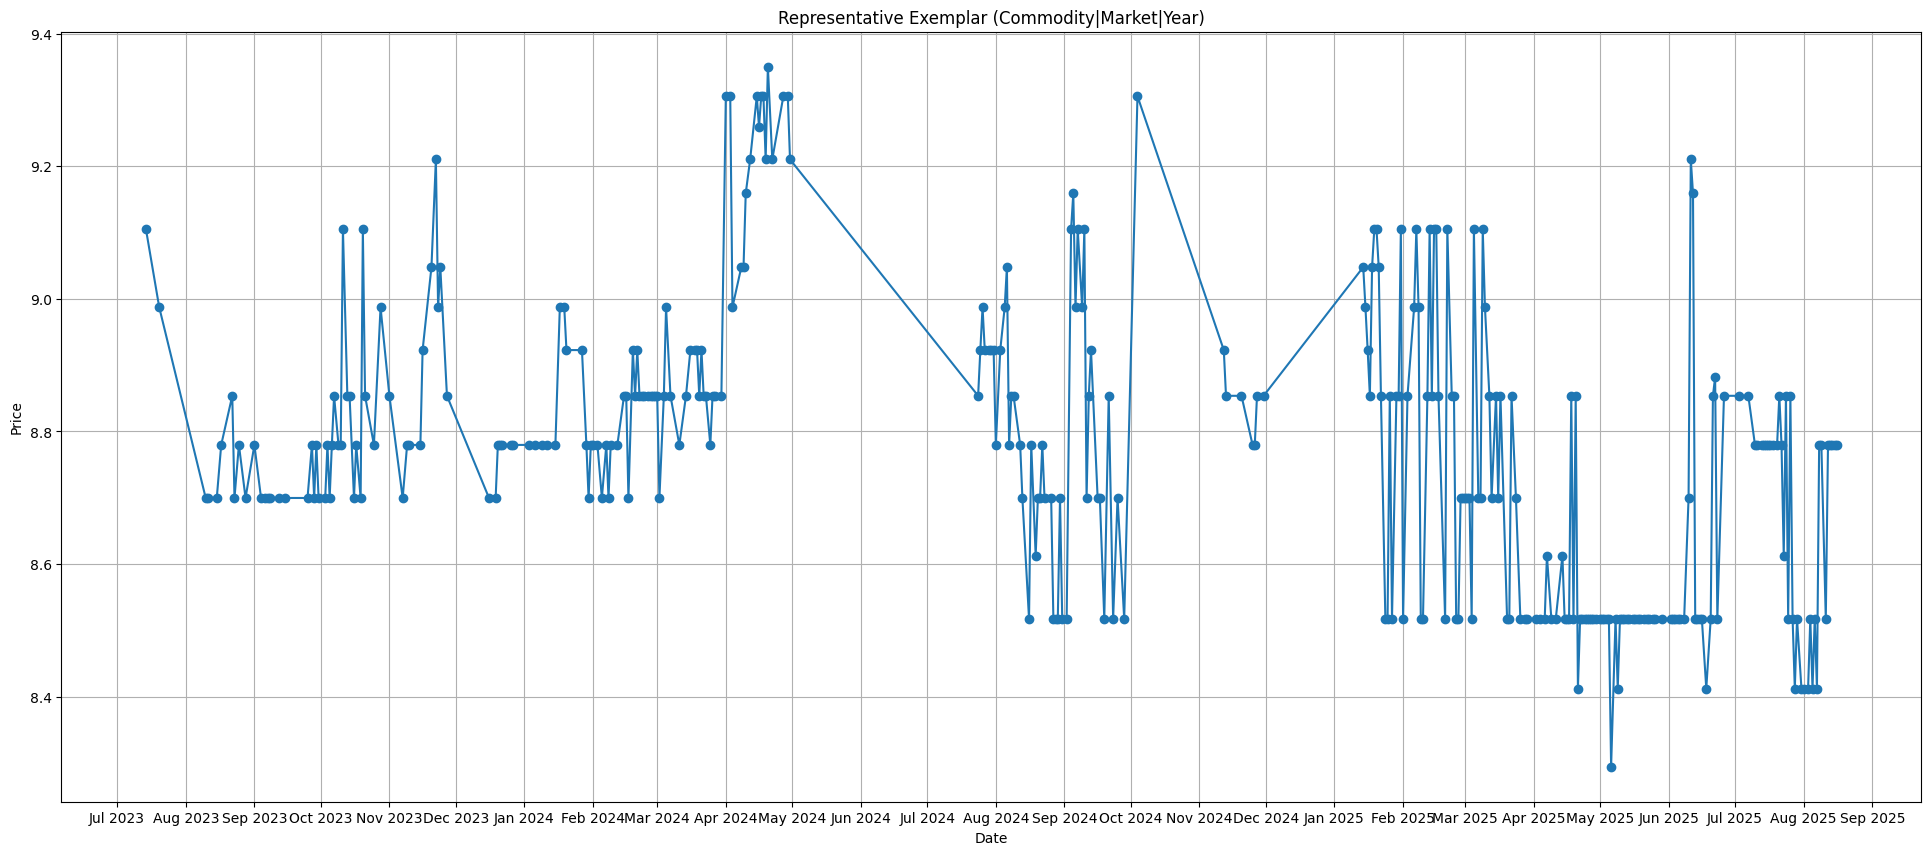

High Volume Product: Indian Beans (Seam)|Other|FAQ
High Volume Market: Thrippunithura


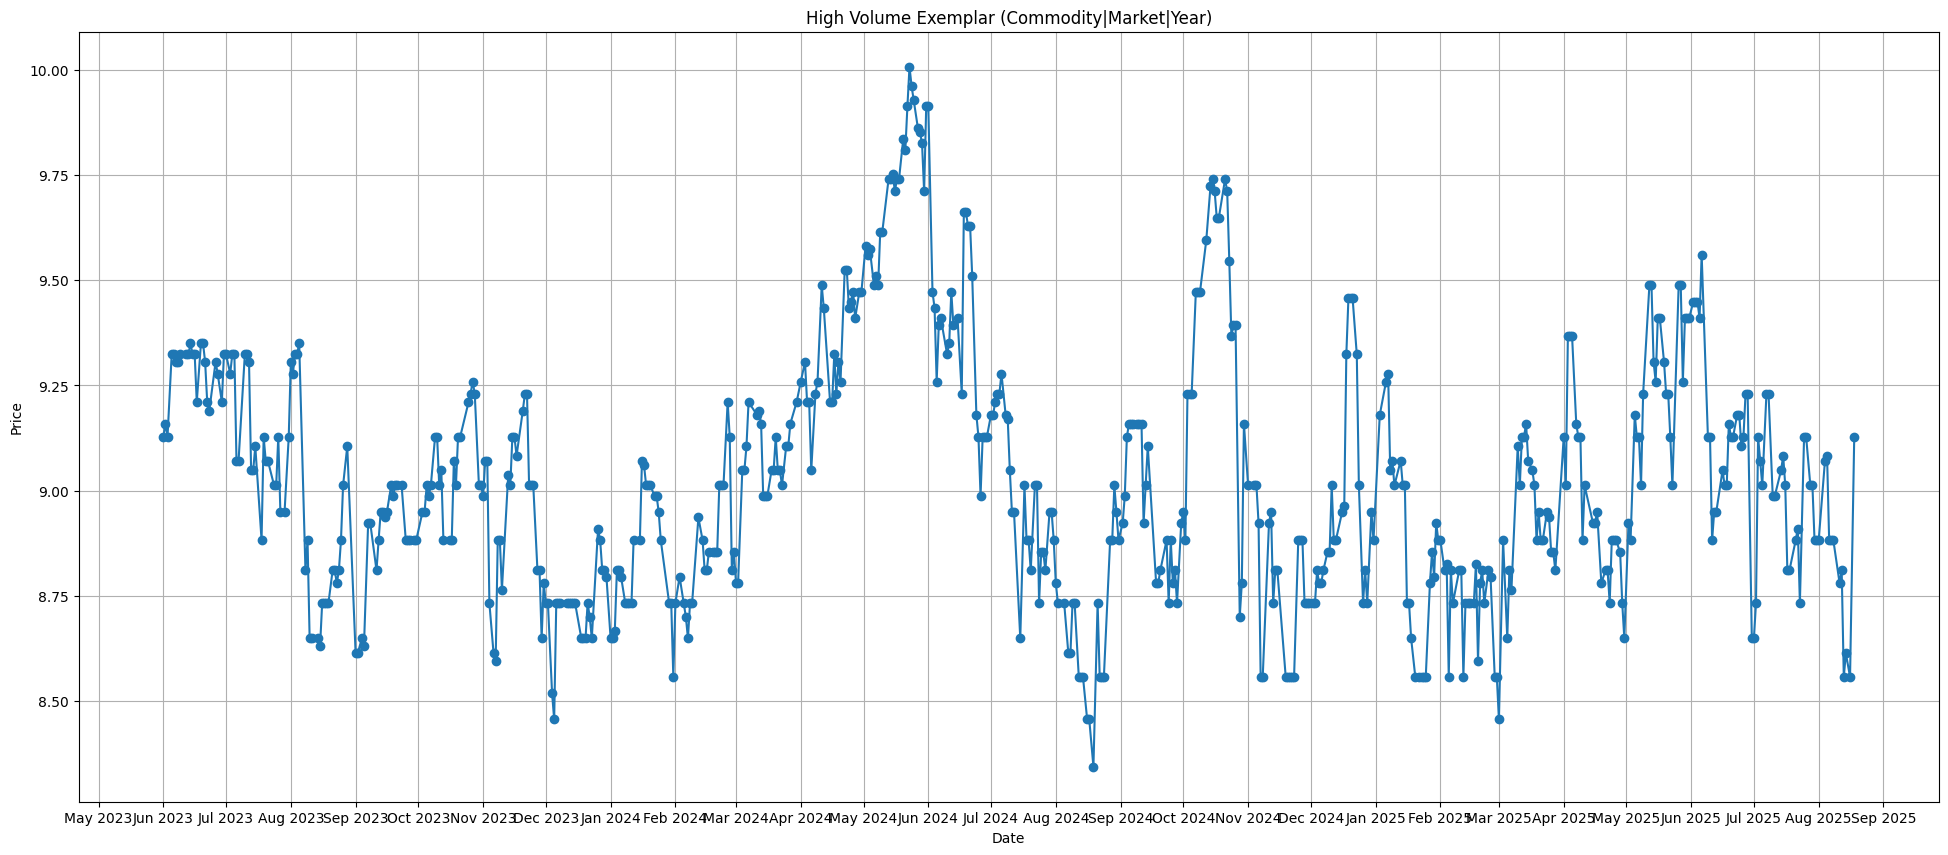

Feature: Commodity|Season
Different exemplars → plotting both
Representative Product: Onion|Big|FAQ
Representative Market: Aluva


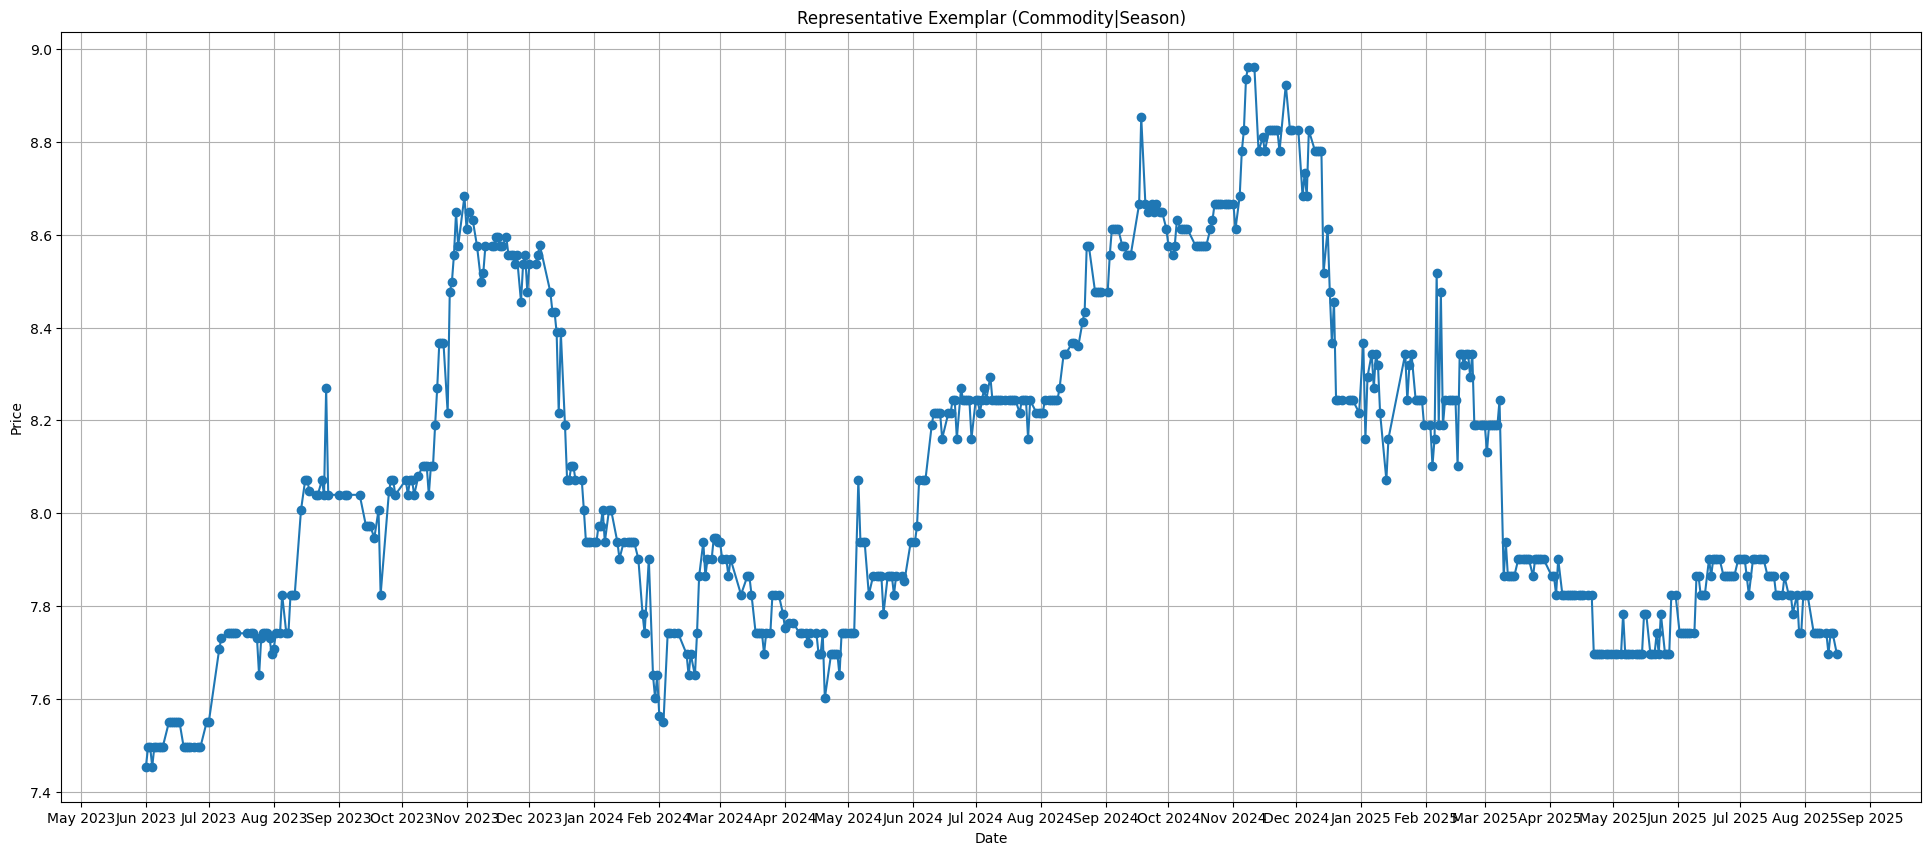

High Volume Product: Onion|Big|FAQ
High Volume Market: Thrippunithura


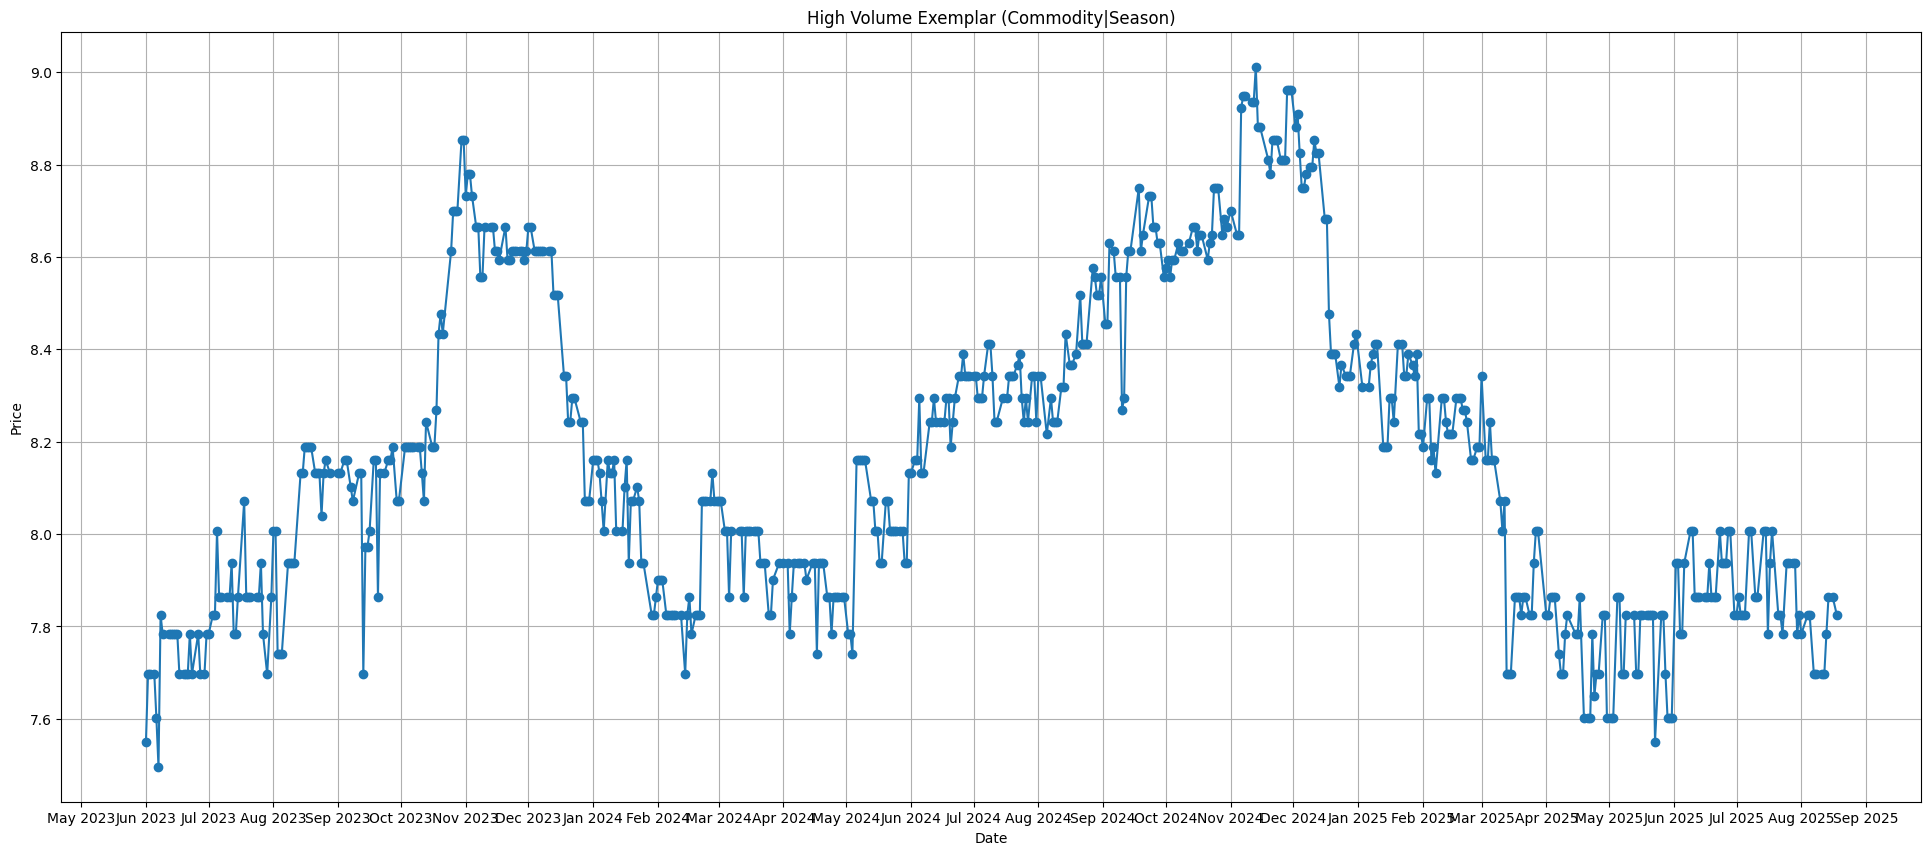

Feature: Commodity|Season|Market
Representative is the same as High Volume exemplar
Product: Cowpea(Veg)|Cowpea (Veg)|FAQ
Market: Aluva


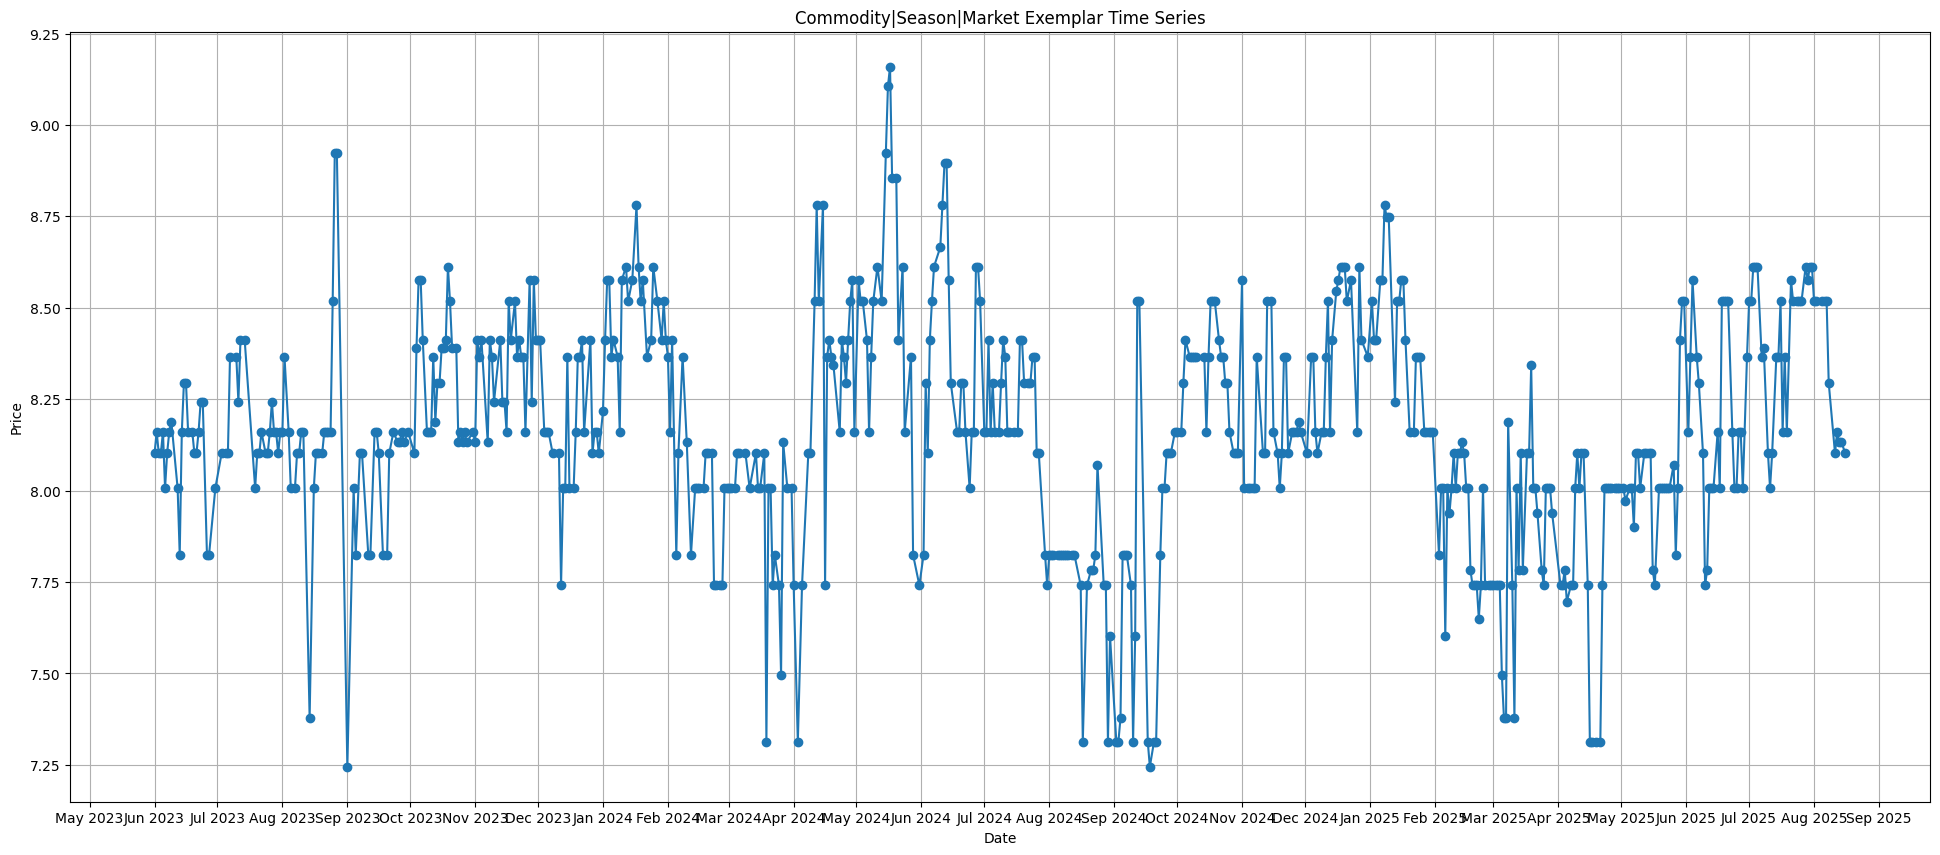

Feature: Commodity|Season|Market|Year
Different exemplars → plotting both
Representative Product: Banana|Poovan|Large
Representative Market: Amalapuram  VFPCK


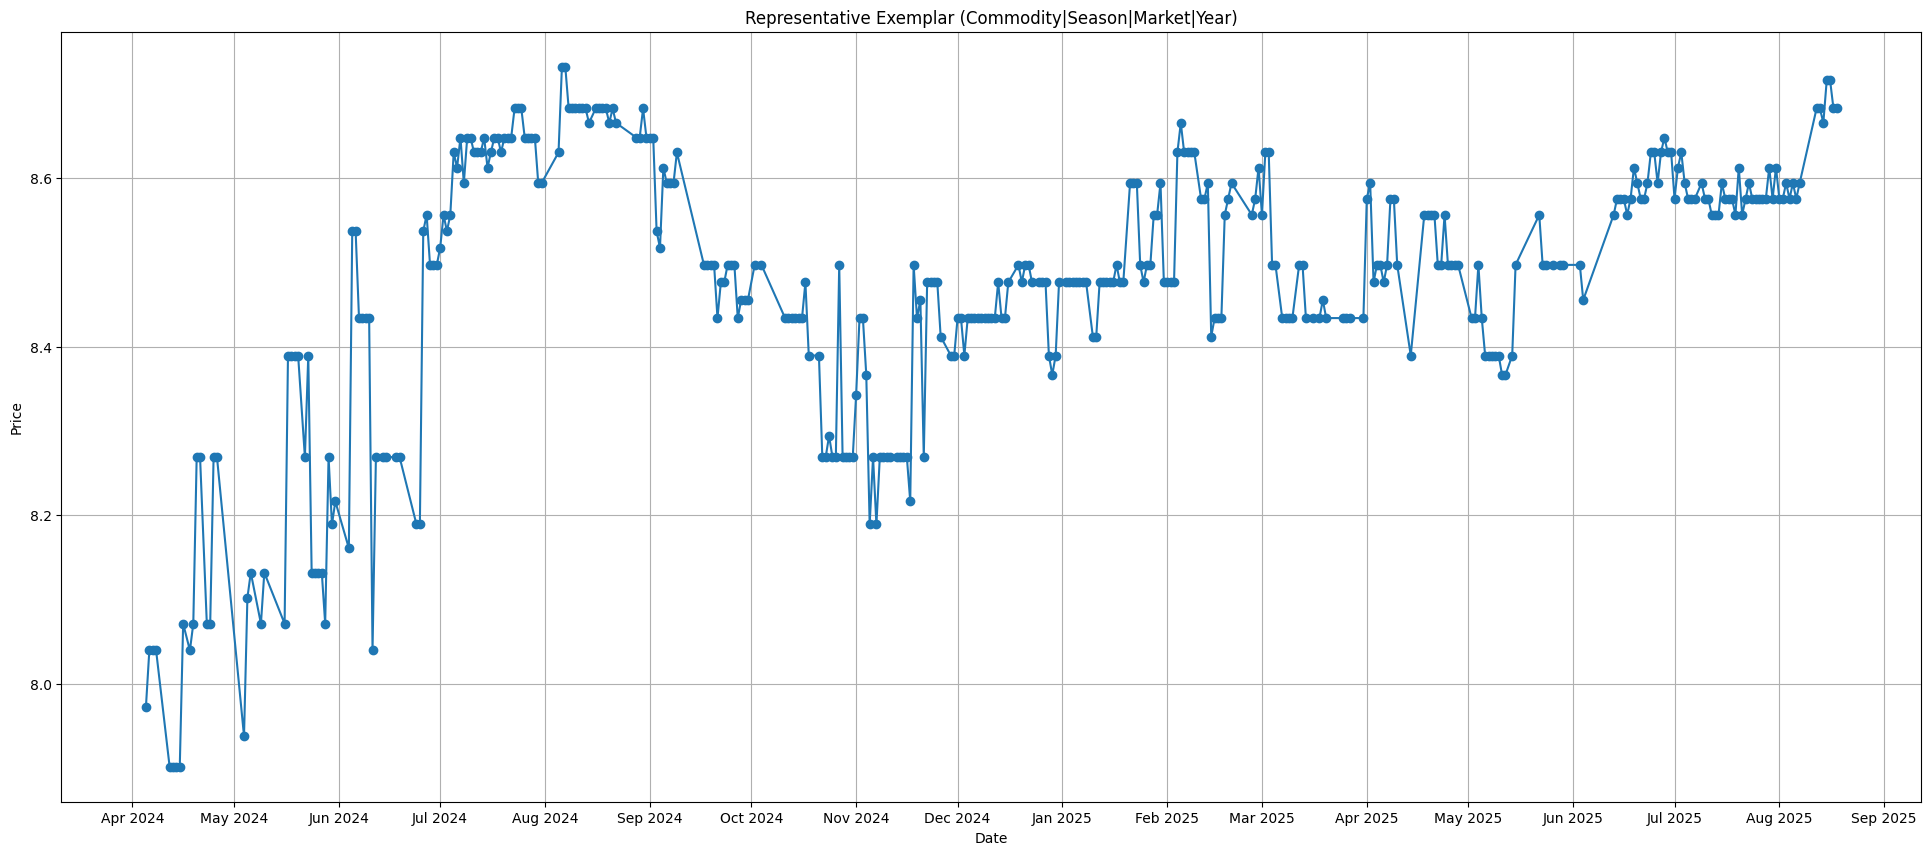

High Volume Product: Potato|Potato|FAQ
High Volume Market: Perumbavoor


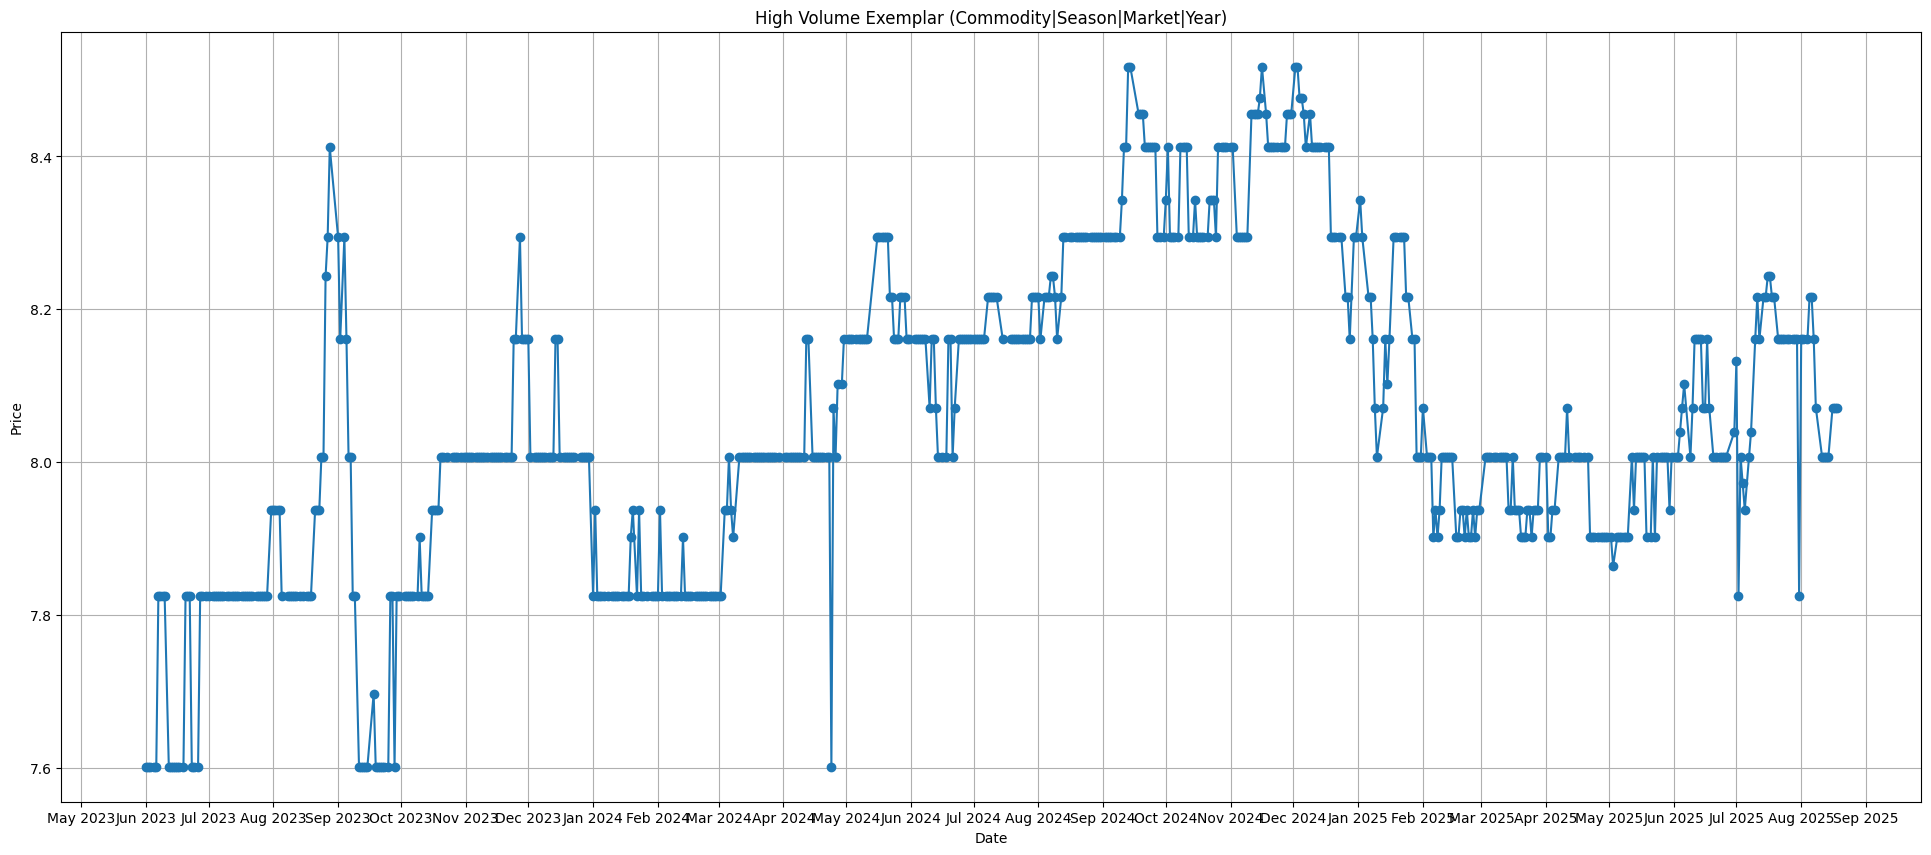

Feature: Commodity|Season|Year
Different exemplars → plotting both
Representative Product: Onion|Other|FAQ
Representative Market: Kothamangalam


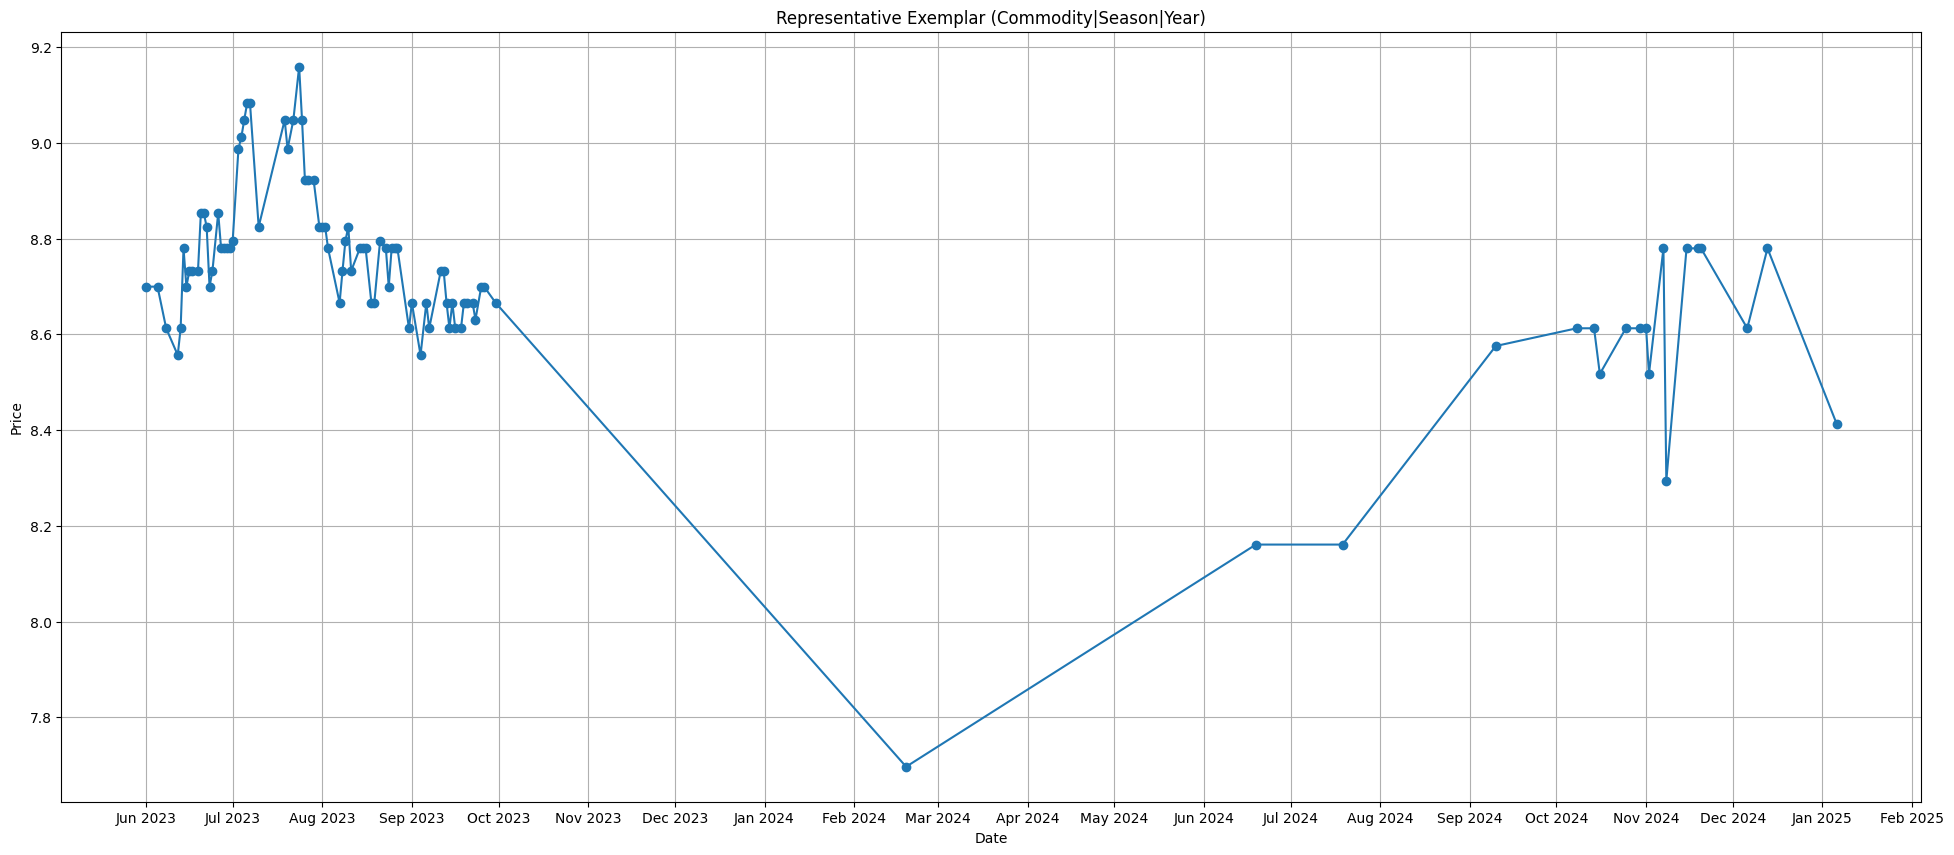

High Volume Product: Onion|Onion|FAQ
High Volume Market: Perumbavoor


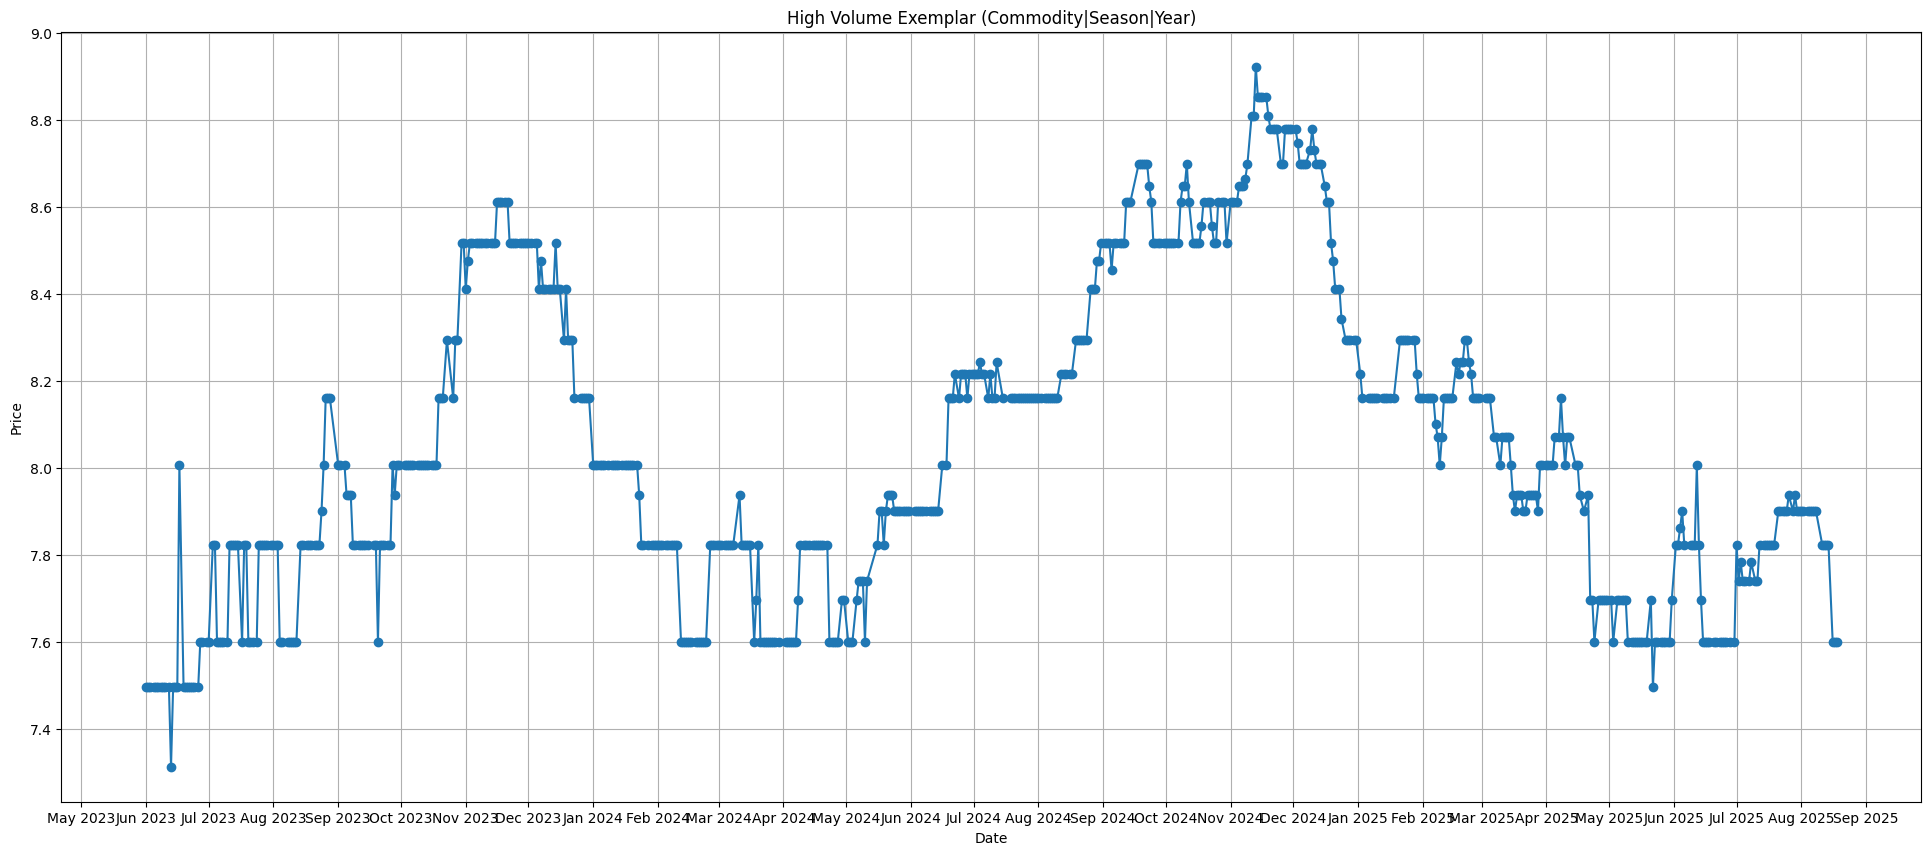

Feature: Commodity|Variety_Type|Market|Year
Different exemplars → plotting both
Representative Product: Pineapple|Other|Medium
Representative Market: Broadway market


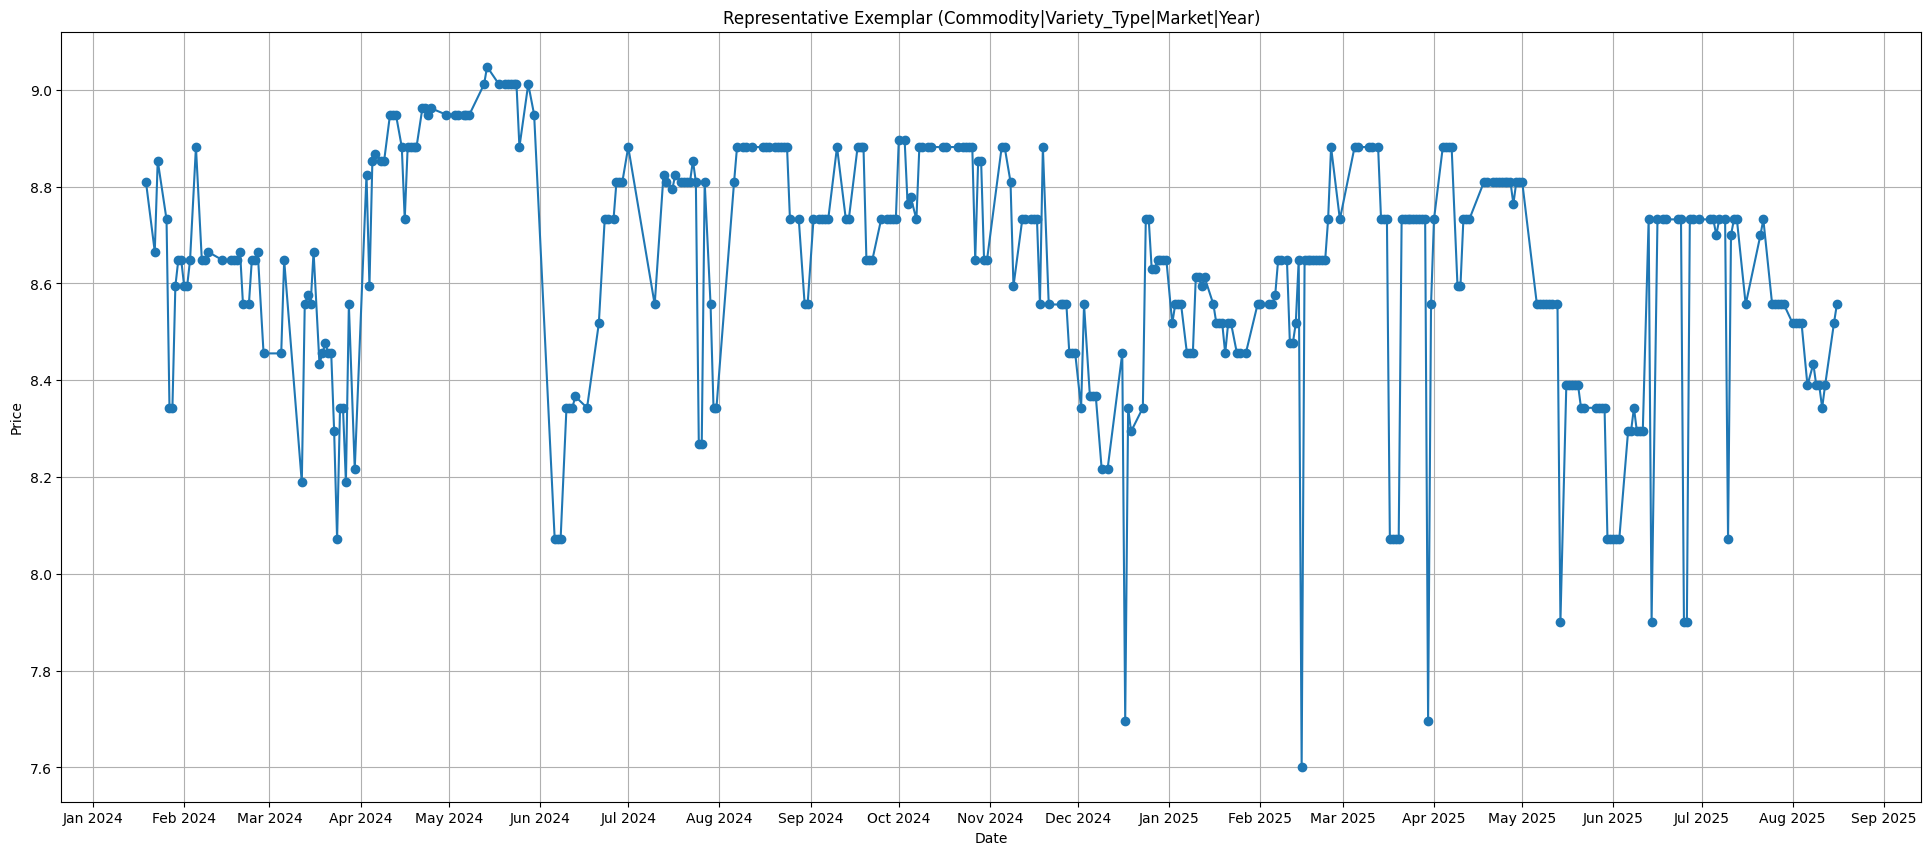

High Volume Product: Pineapple|Other|Medium
High Volume Market: Keezhampara VFPCK


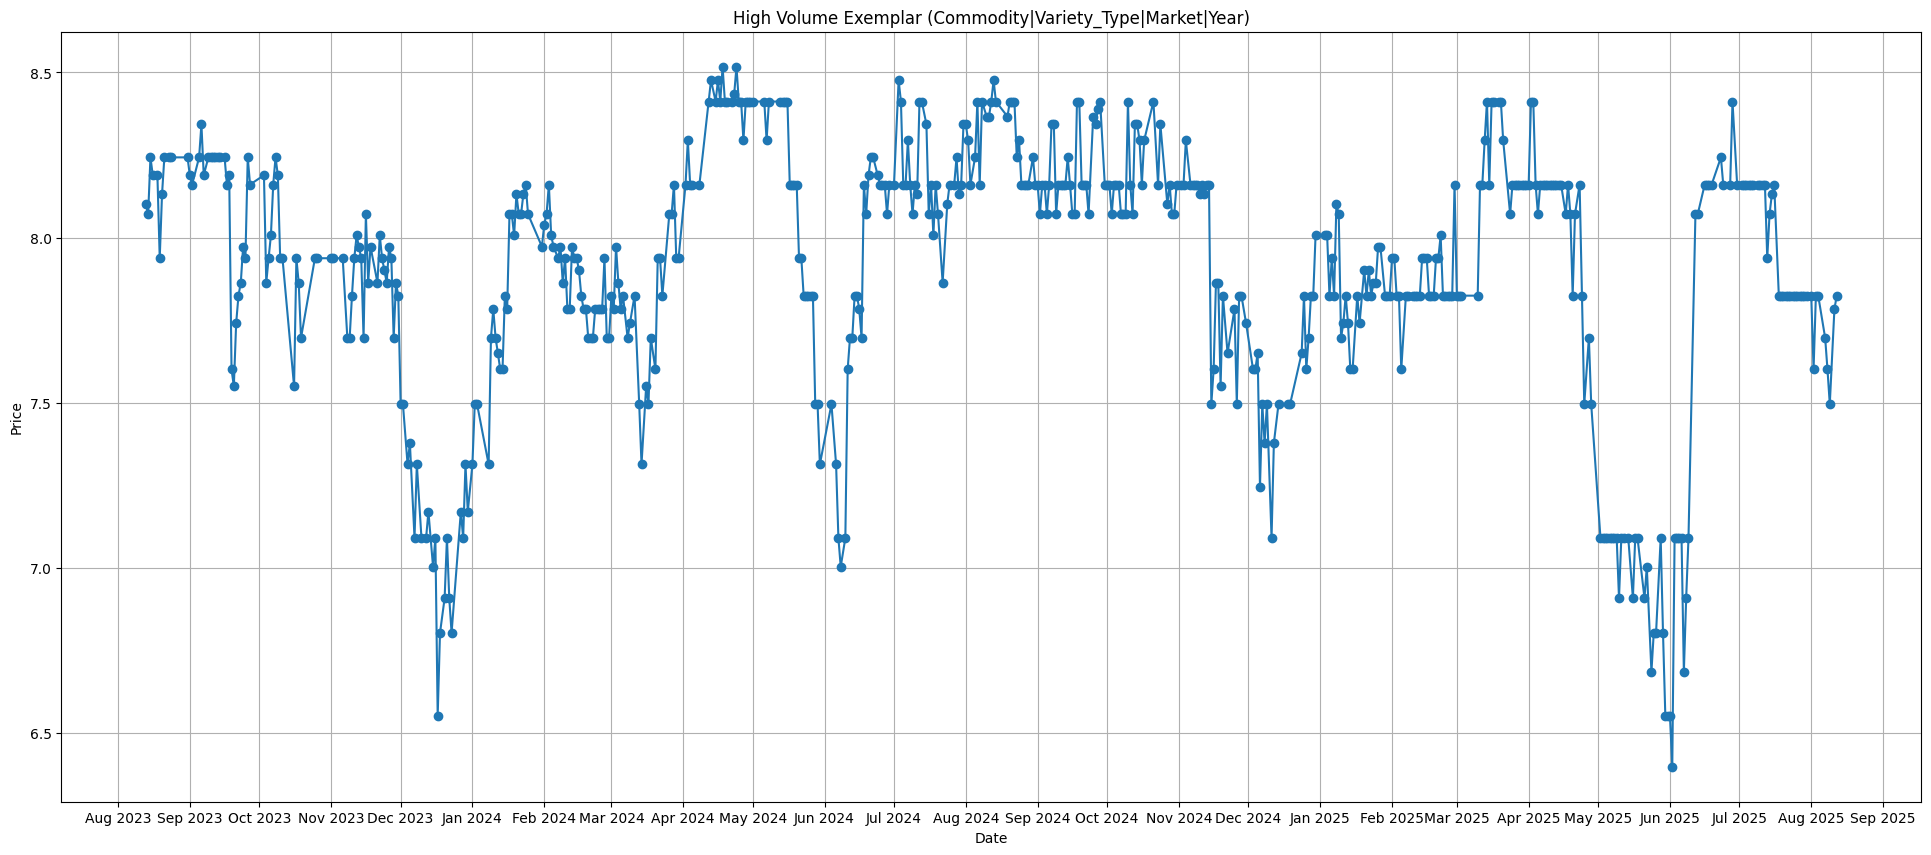

Feature: Commodity|Variety_Type|Season|Market
Different exemplars → plotting both
Representative Product: Banana|Palayamthodan|Large
Representative Market: Amalapuram  VFPCK


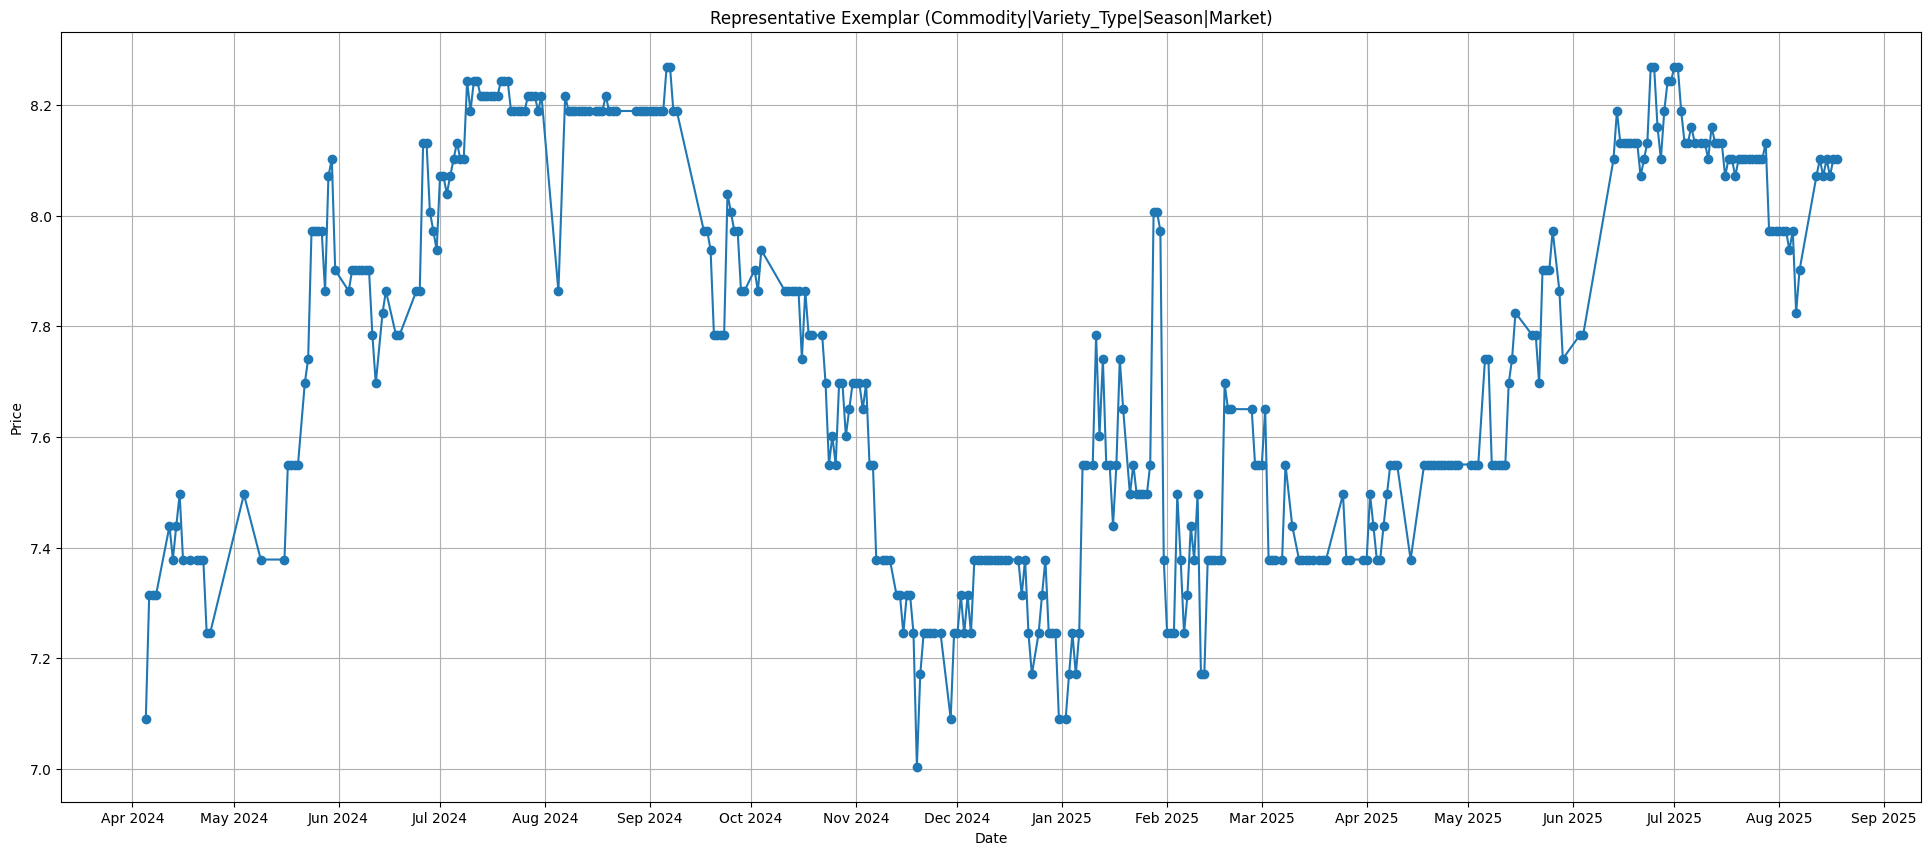

High Volume Product: Banana|Palayamthodan|Medium
High Volume Market: Perumbavoor


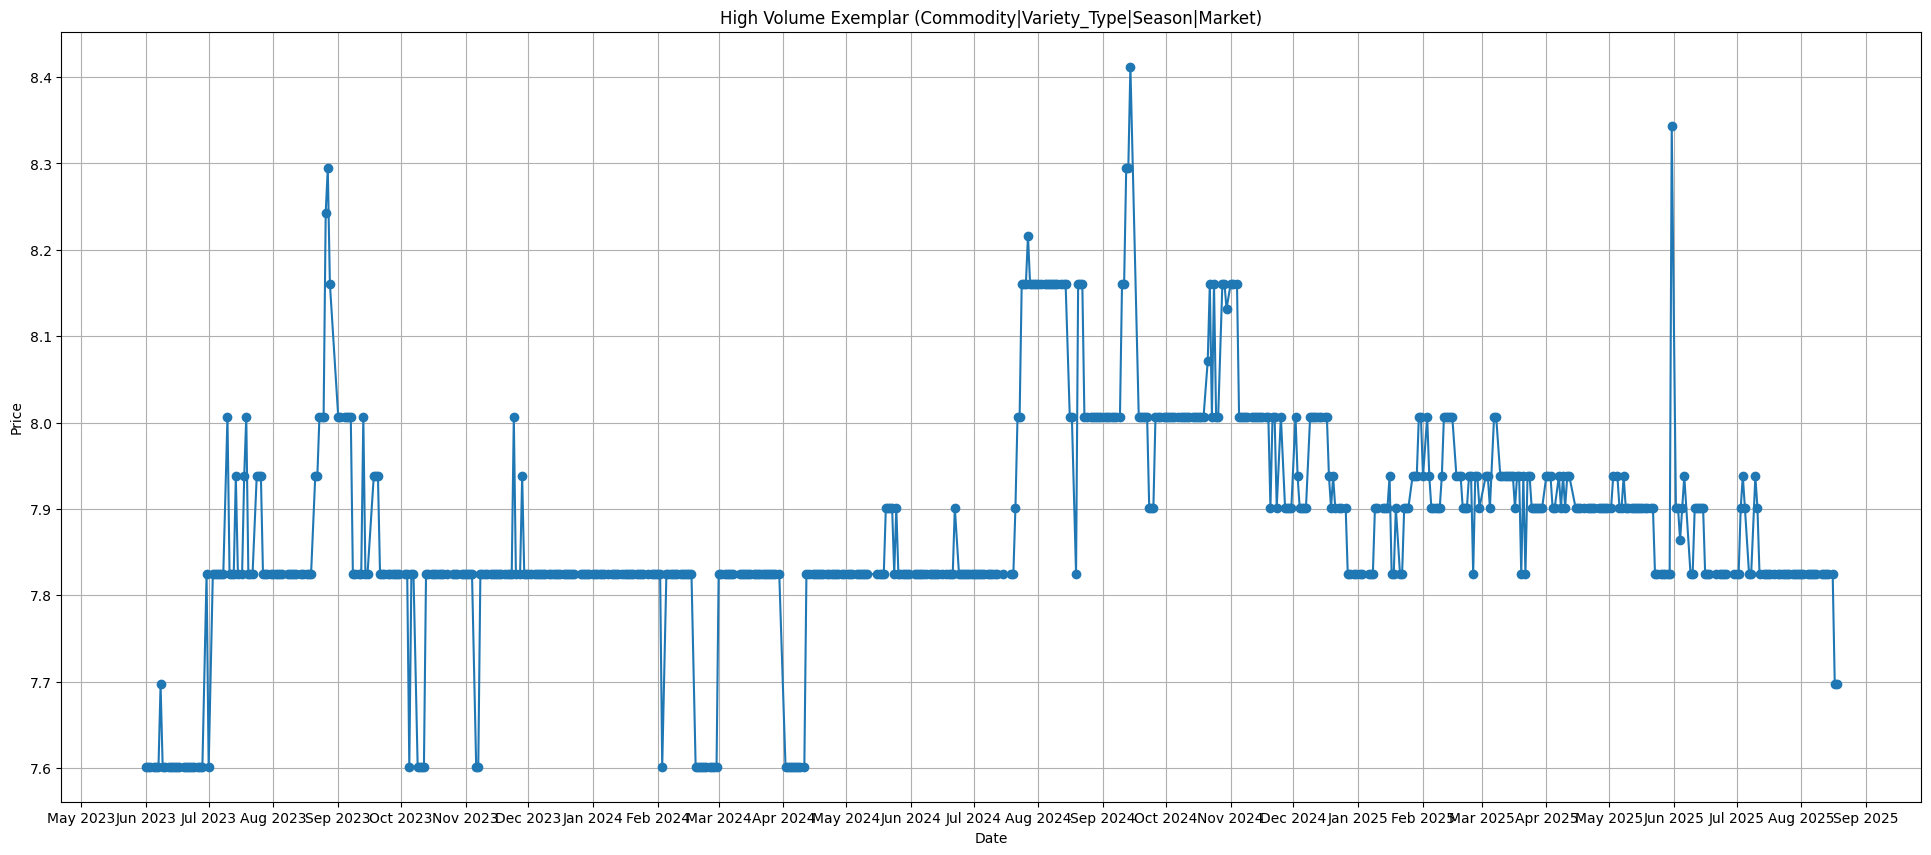

Feature: Commodity|Variety_Type|Season|Market|Year
Representative is the same as High Volume exemplar
Product: Pineapple|Other|Large
Market: Keezhampara VFPCK


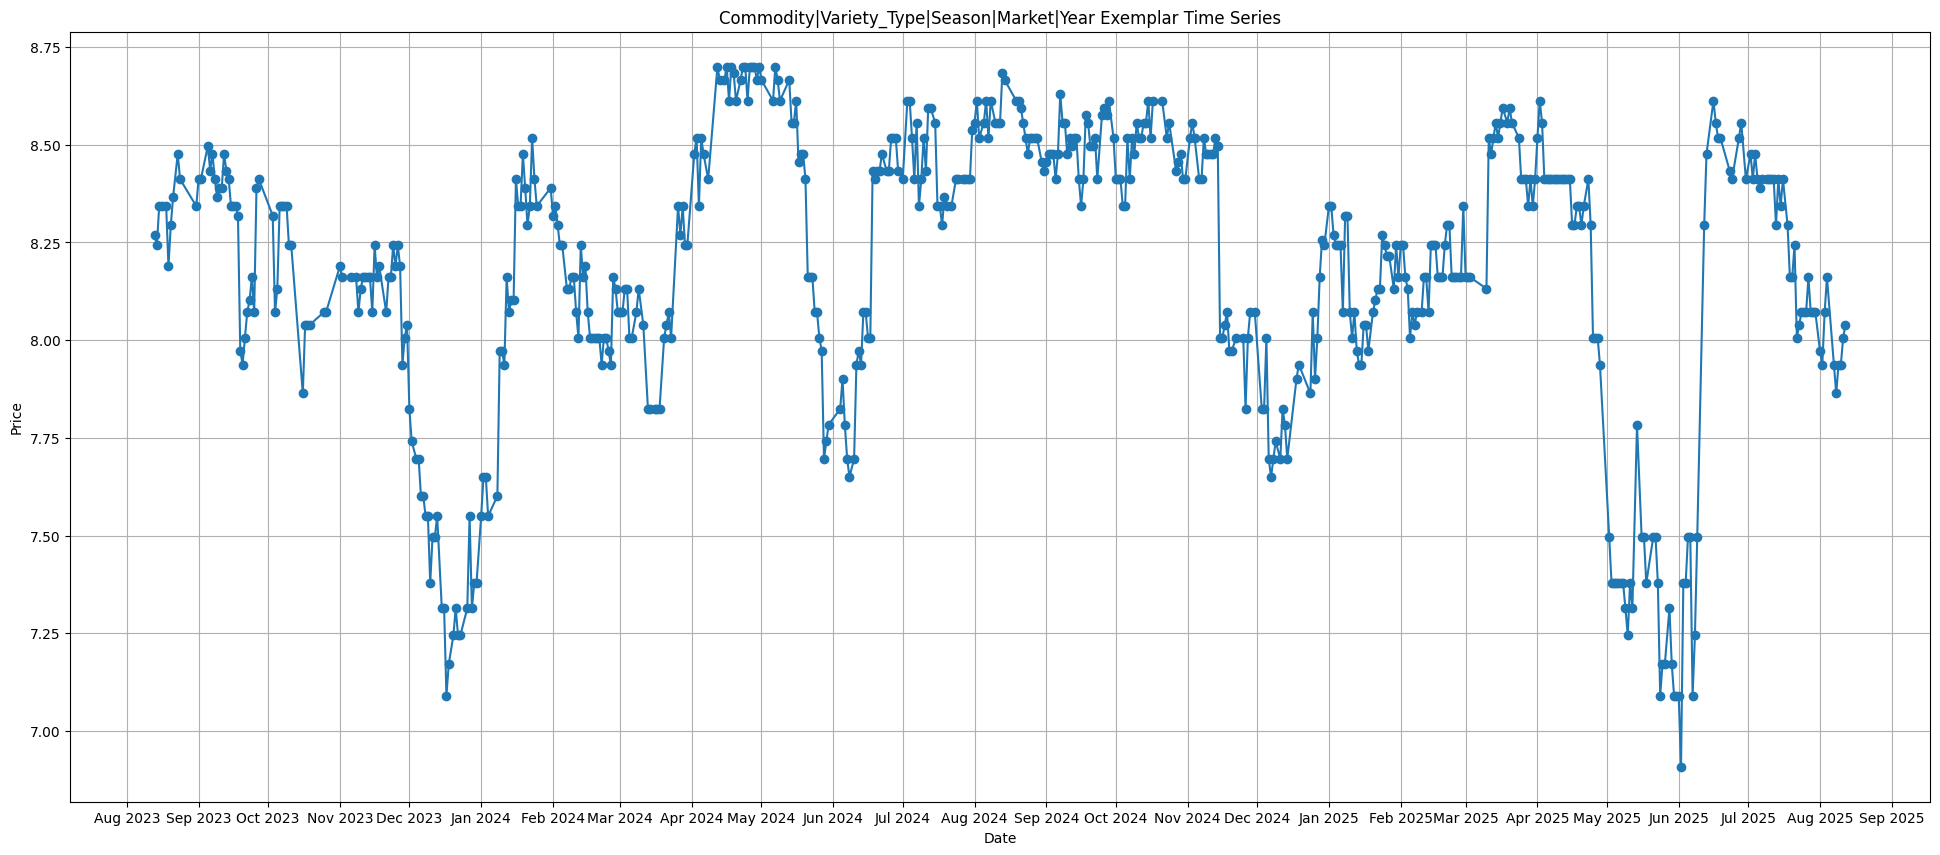

Feature: Commodity|Variety_Type|Season|Year
Different exemplars → plotting both
Representative Product: Potato|(Red Nanital)|FAQ
Representative Market: North Paravur


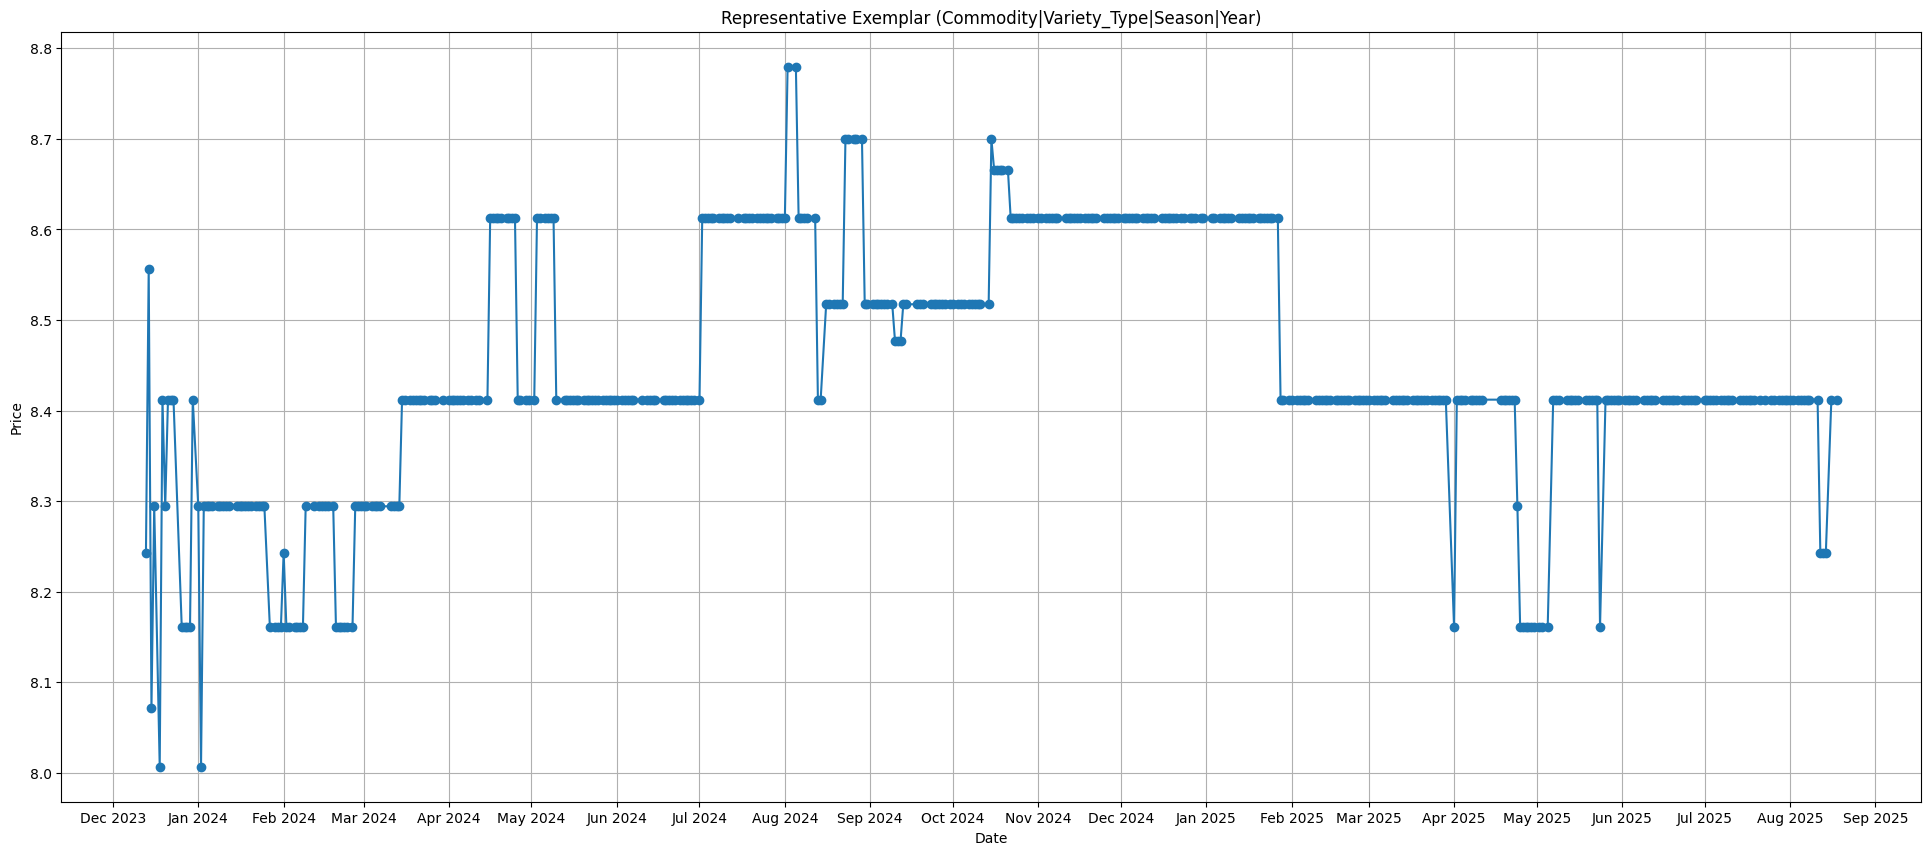

High Volume Product: Pineapple|Other|Small
High Volume Market: Keezhampara VFPCK


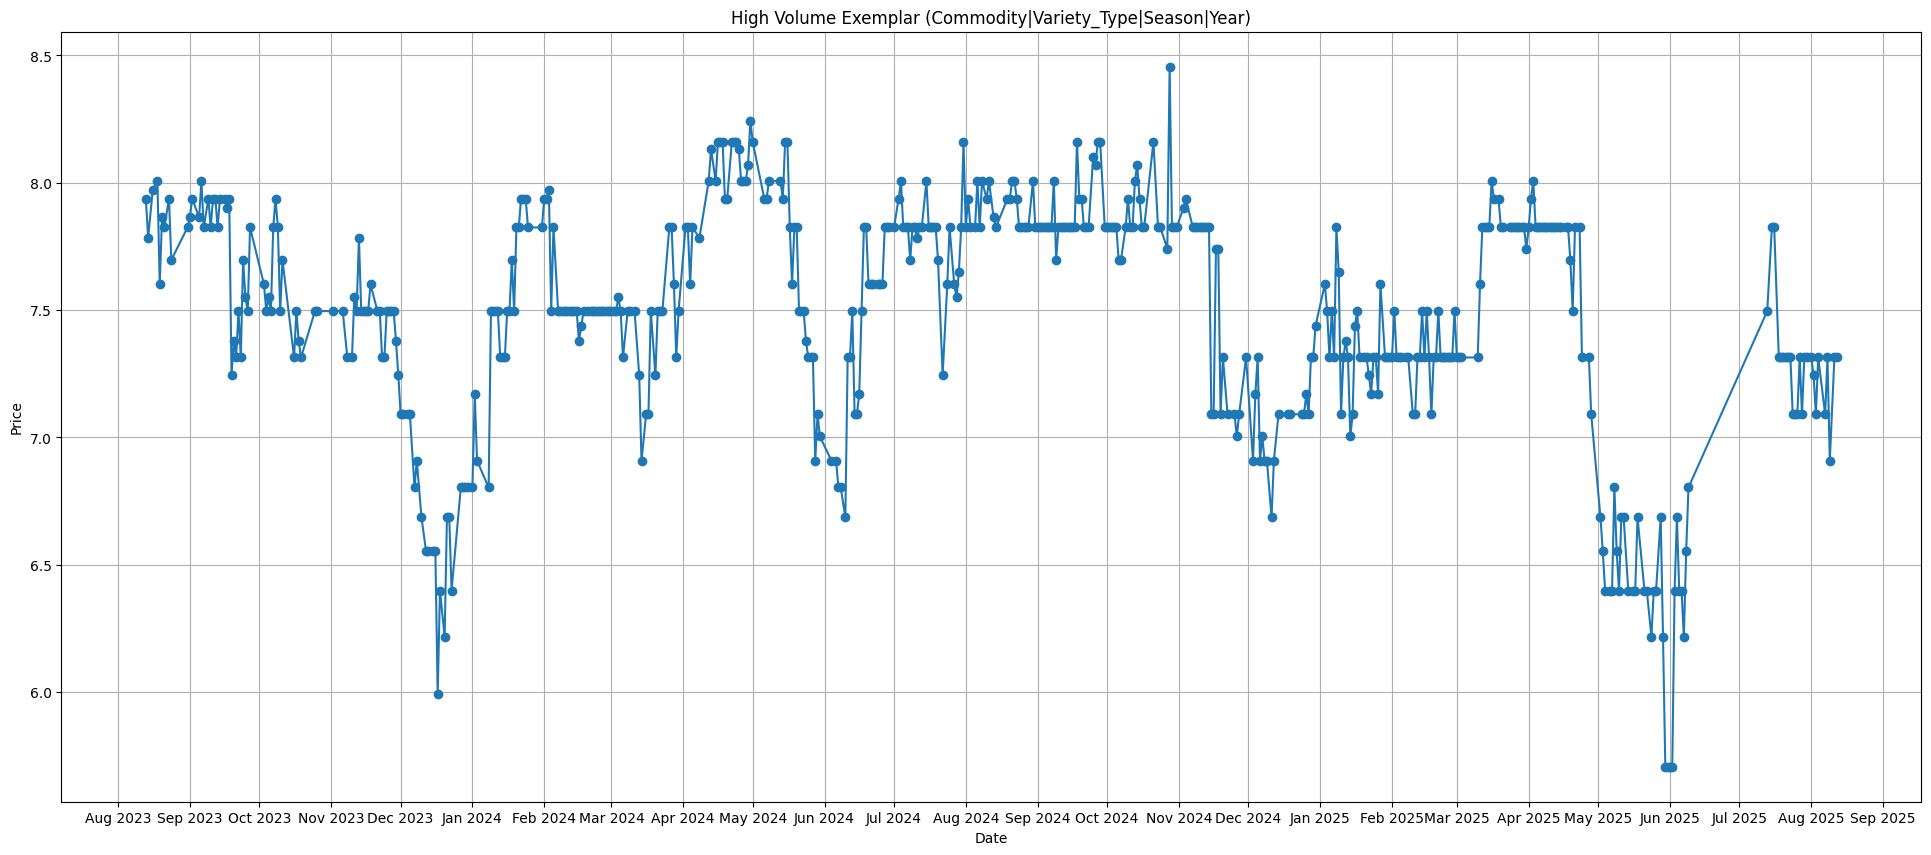

Feature: Commodity|Year
Representative is the same as High Volume exemplar
Product: Field Pea|Other|FAQ
Market: Kothamangalam


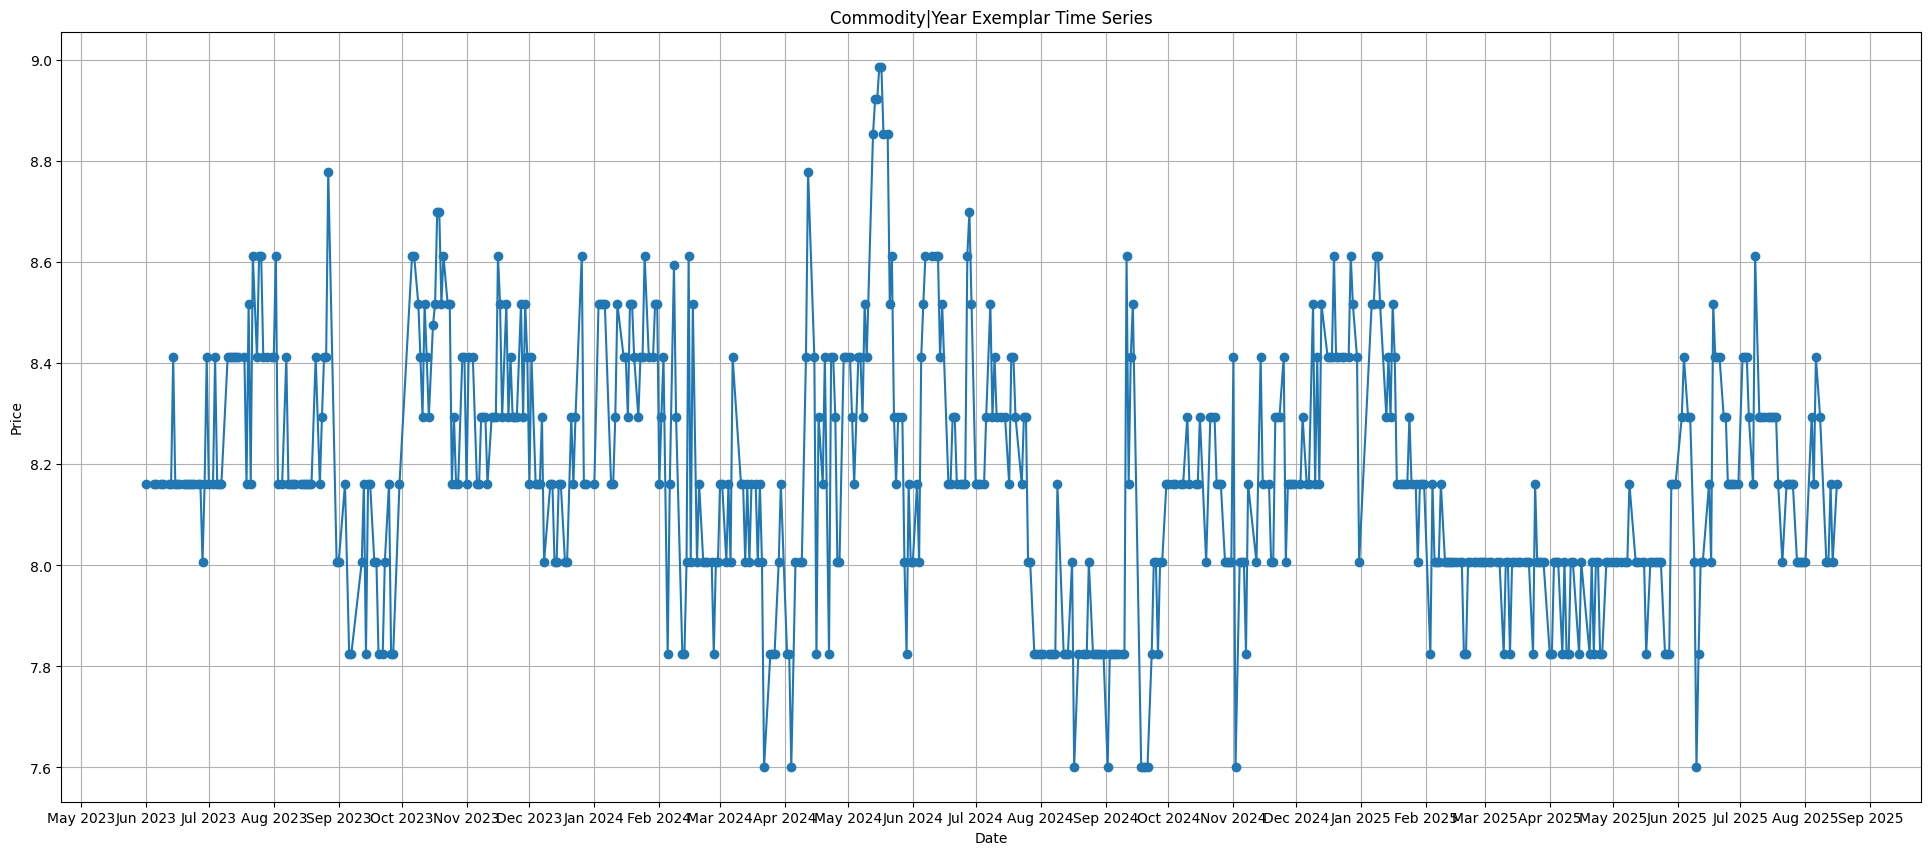

Feature: Market|Year
Different exemplars → plotting both
Representative Product: Beetroot|Beetroot|FAQ
Representative Market: Angamaly


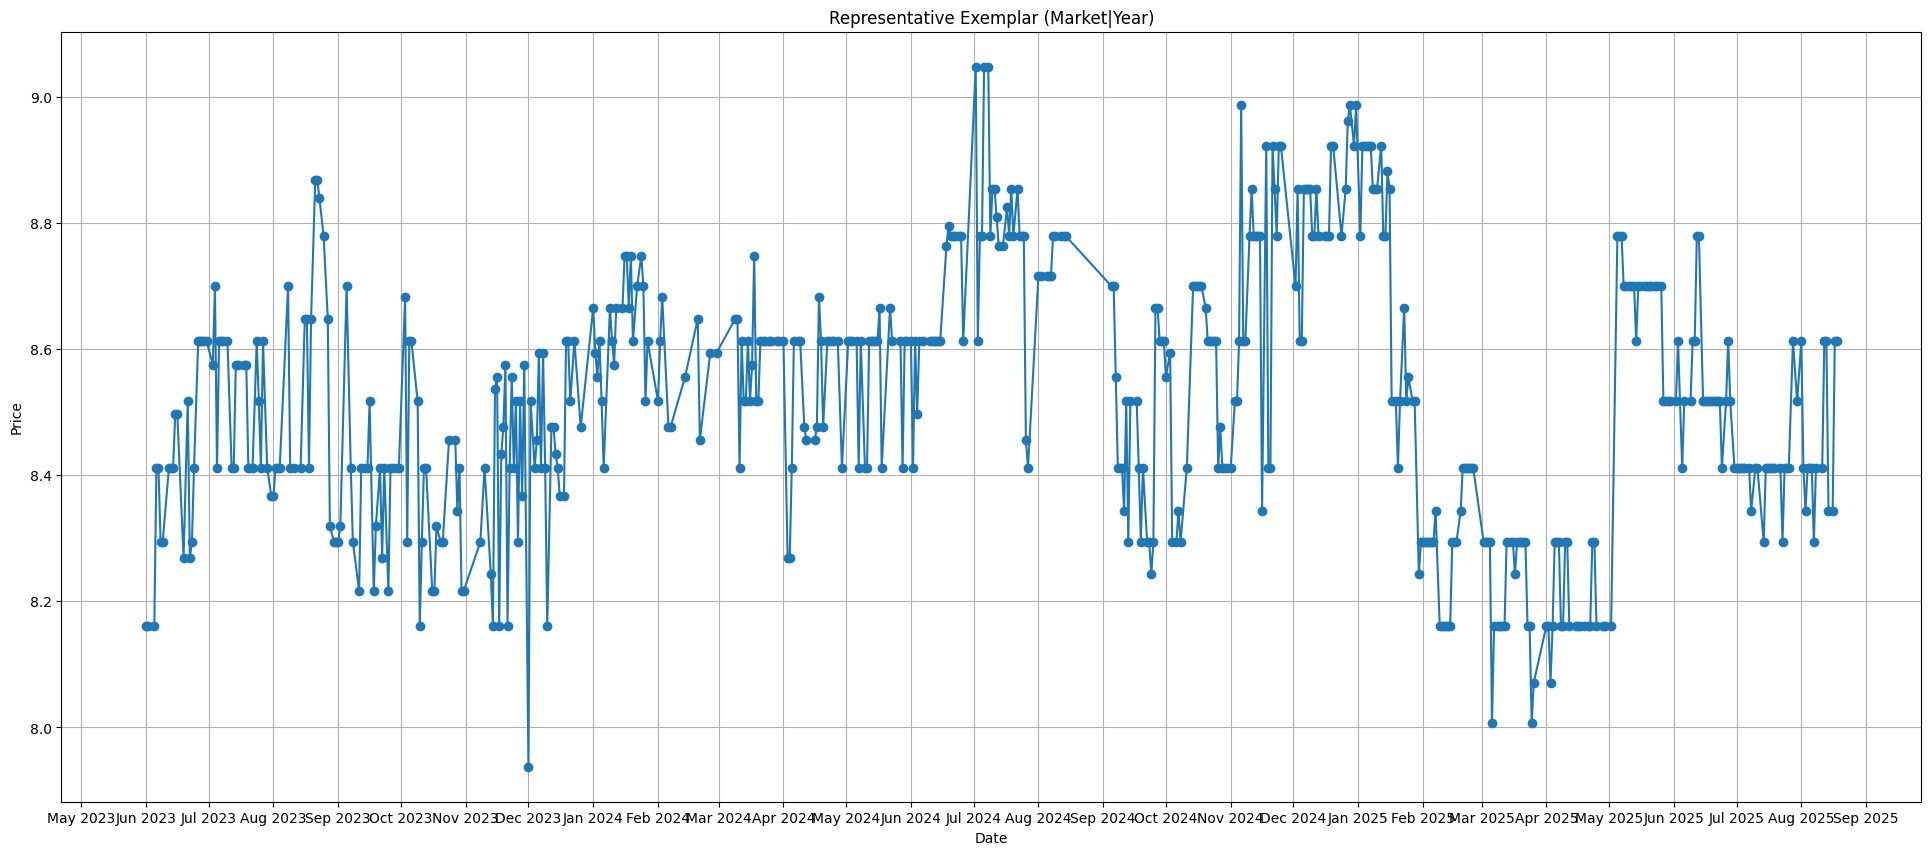

High Volume Product: Cabbage|Cabbage|FAQ
High Volume Market: Perumbavoor


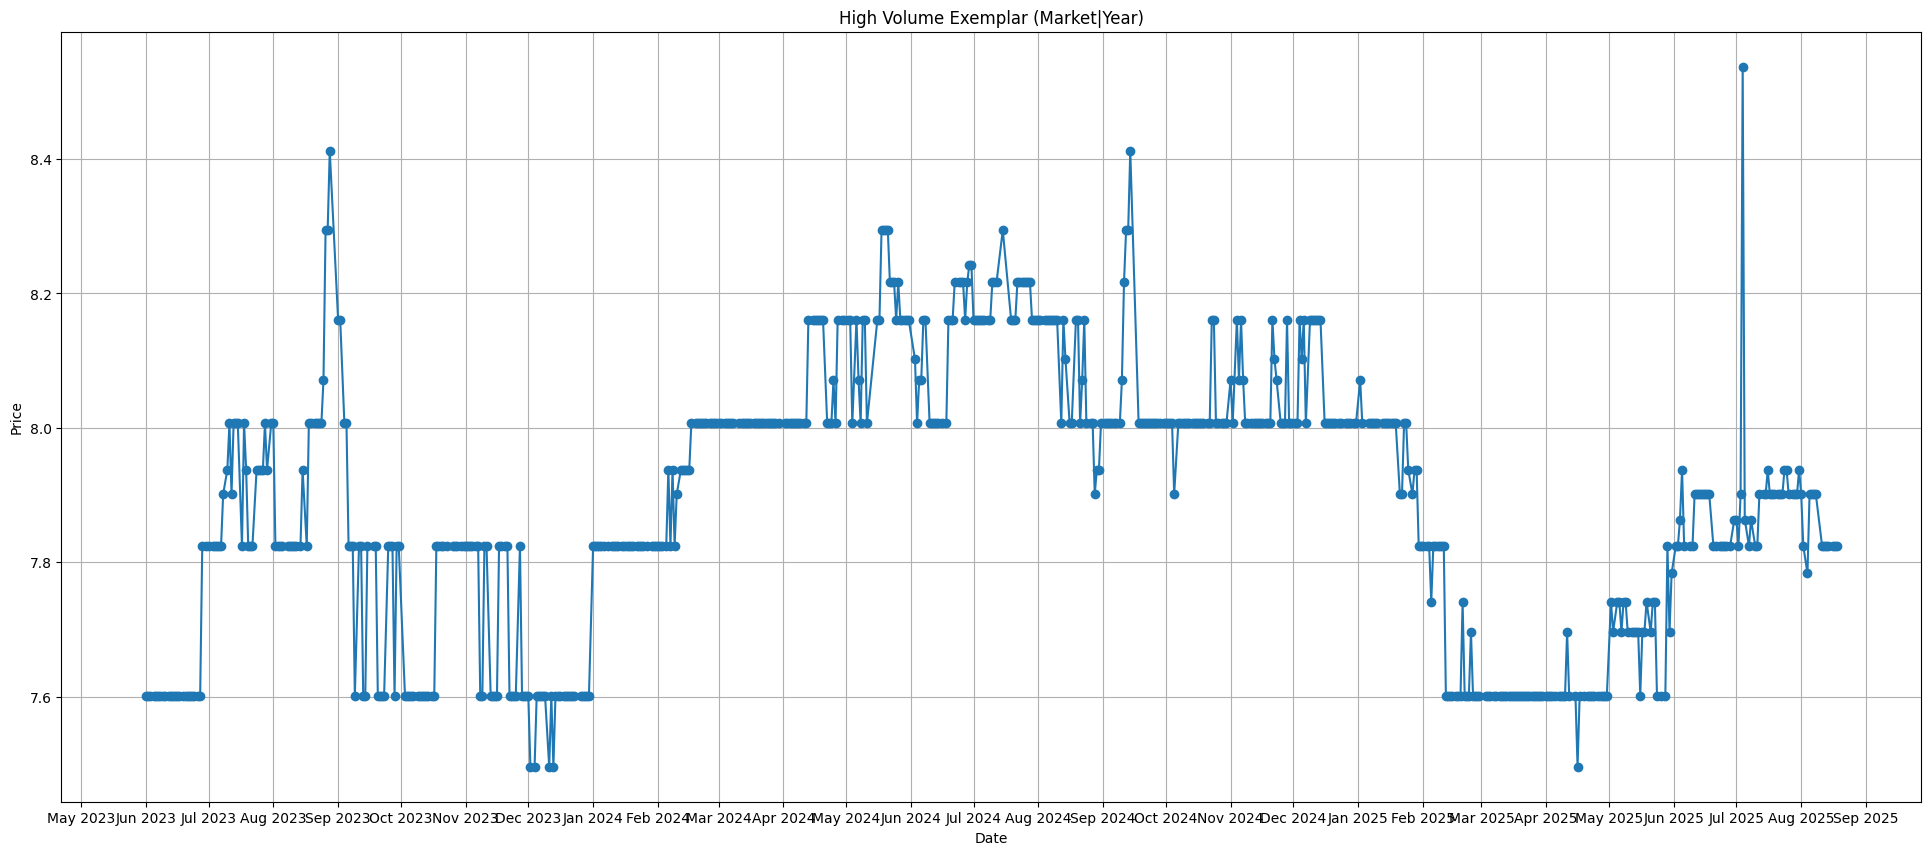

Feature: Season
Different exemplars → plotting both
Representative Product: Mango (Raw-Ripe)|Other|FAQ
Representative Market: Kothamangalam


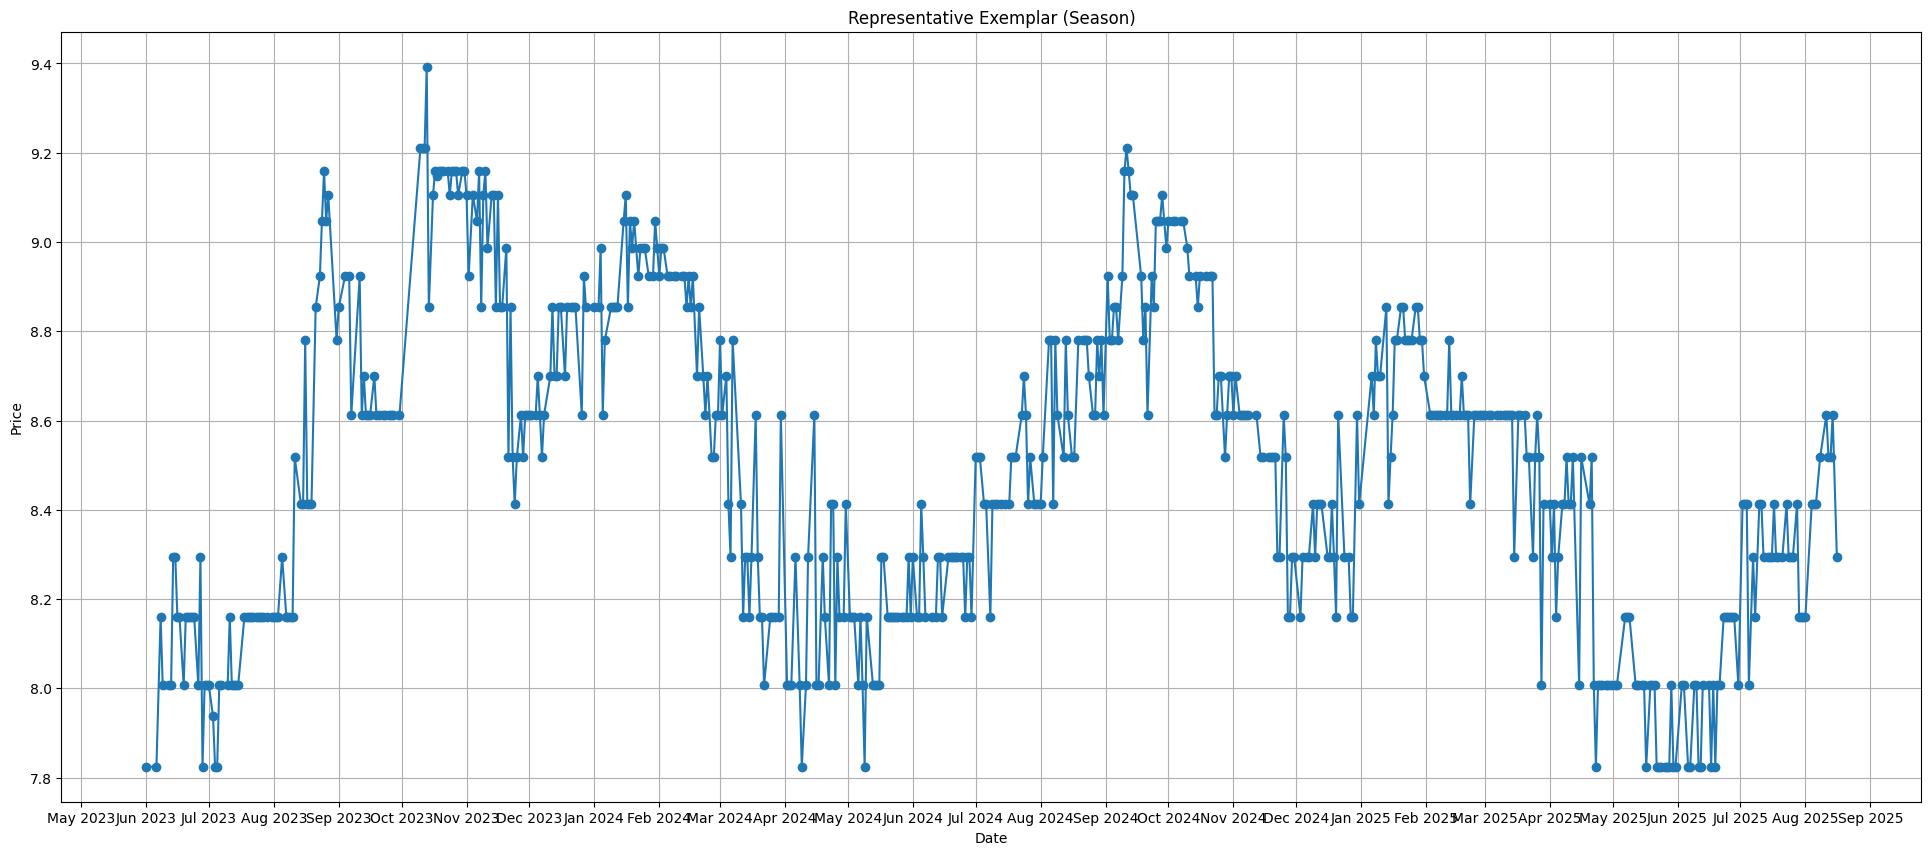

High Volume Product: Drumstick|Drumstick|FAQ
High Volume Market: Perumbavoor


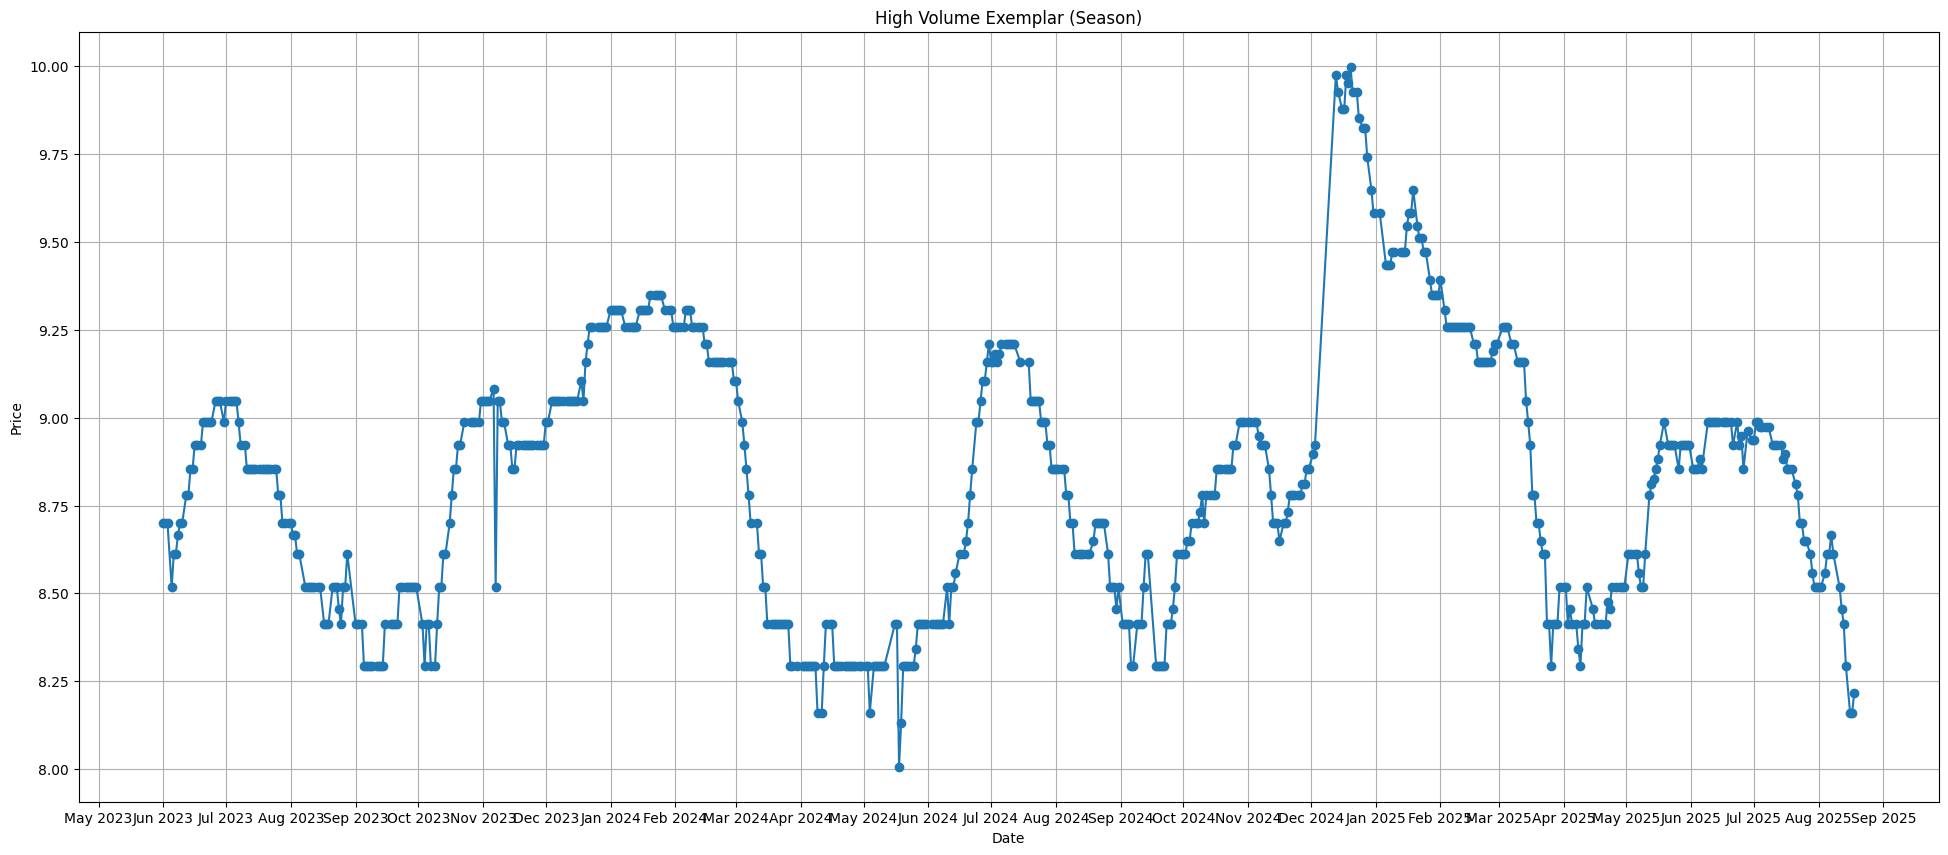

Feature: Season|Market
Different exemplars → plotting both
Representative Product: Ashgourd|Ashgourd|FAQ
Representative Market: Aluva


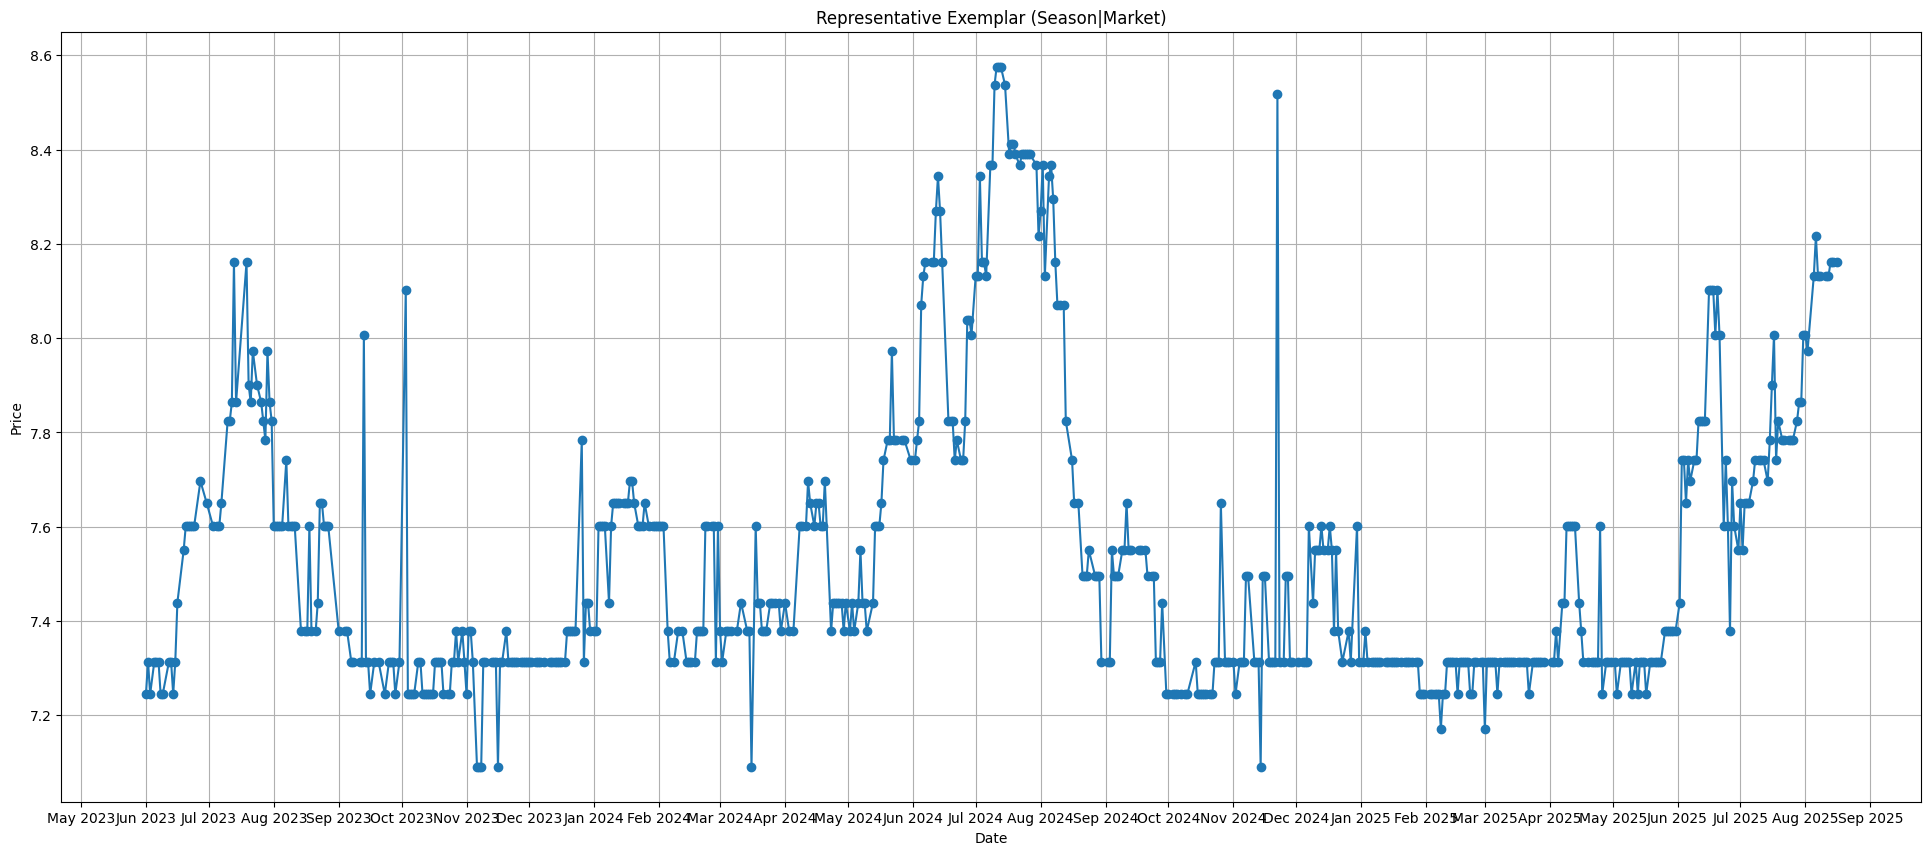

High Volume Product: Bitter gourd|Bitter Gourd|FAQ
High Volume Market: Perumbavoor


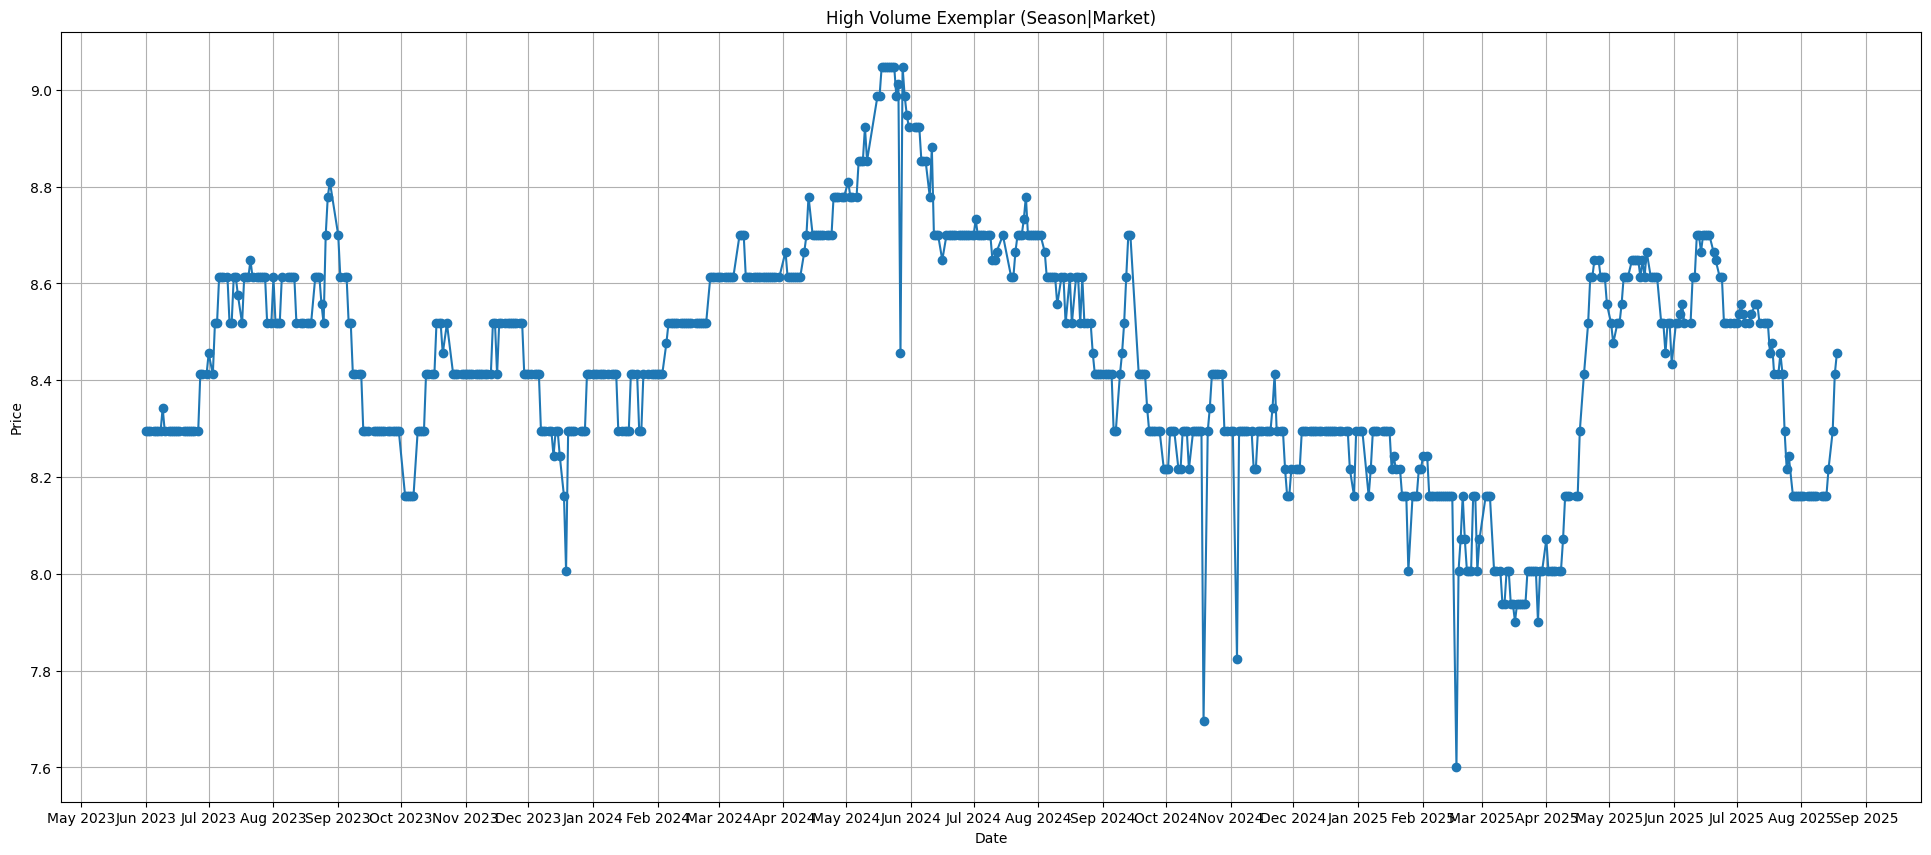

Feature: Season|Market|Year
Different exemplars → plotting both
Representative Product: Amphophalus|Amphophalus|FAQ
Representative Market: Angamaly


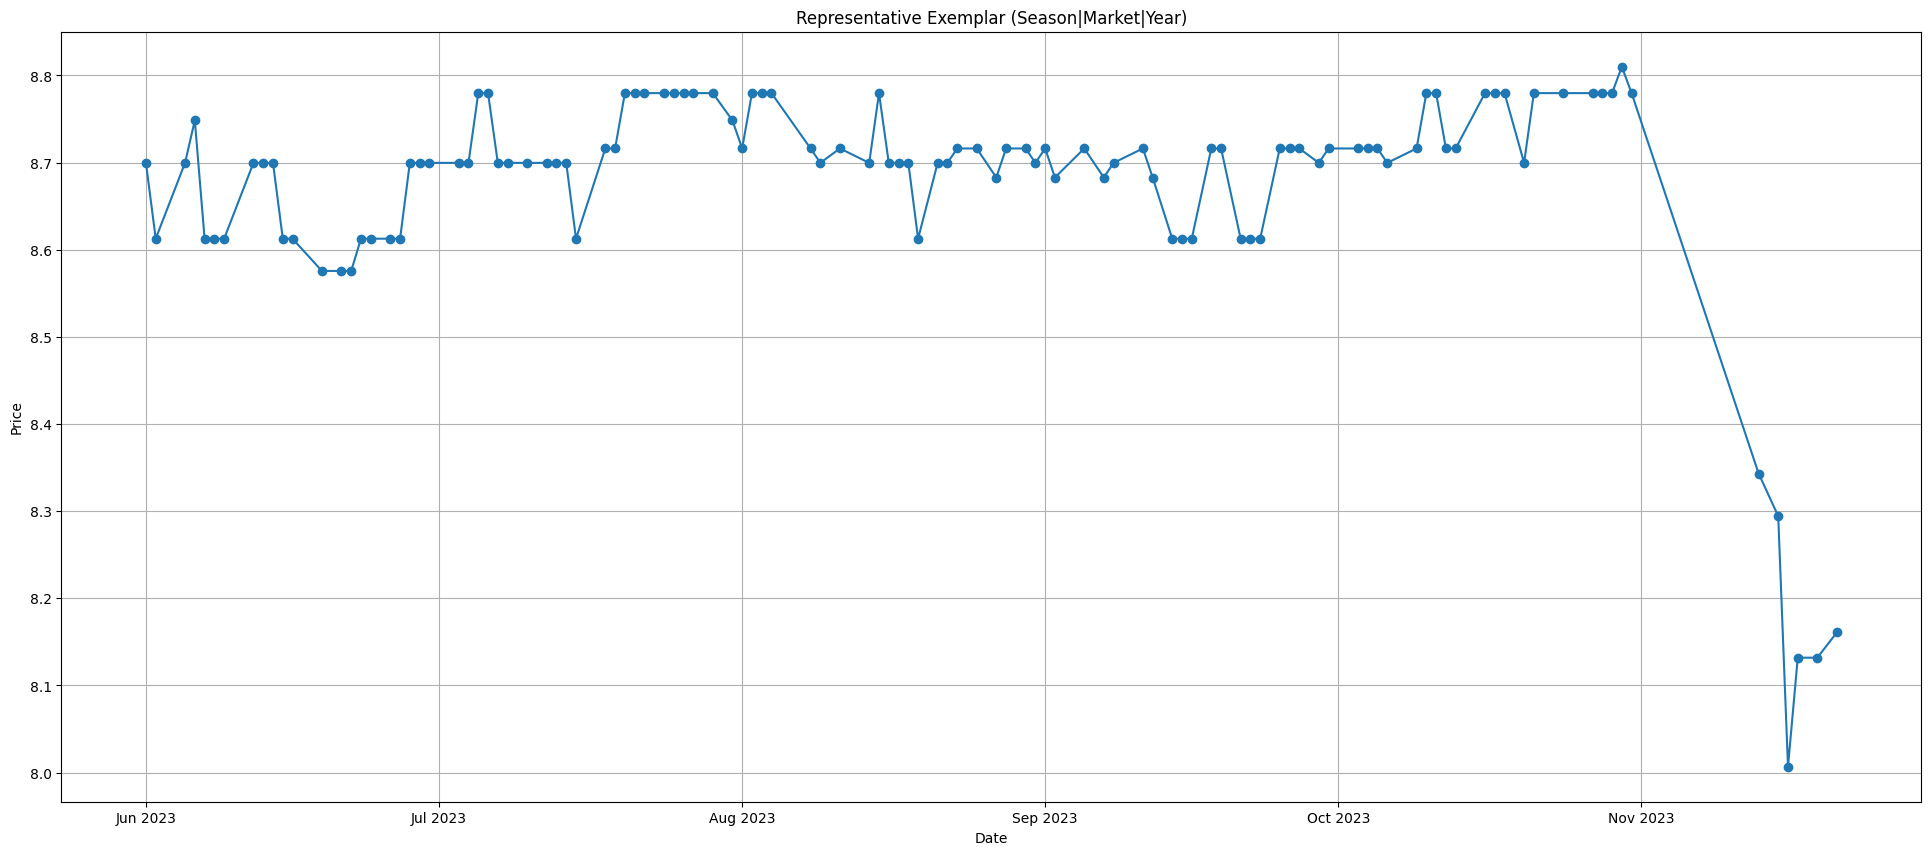

High Volume Product: Banana - Green|Banana - Green|FAQ
High Volume Market: Perumbavoor


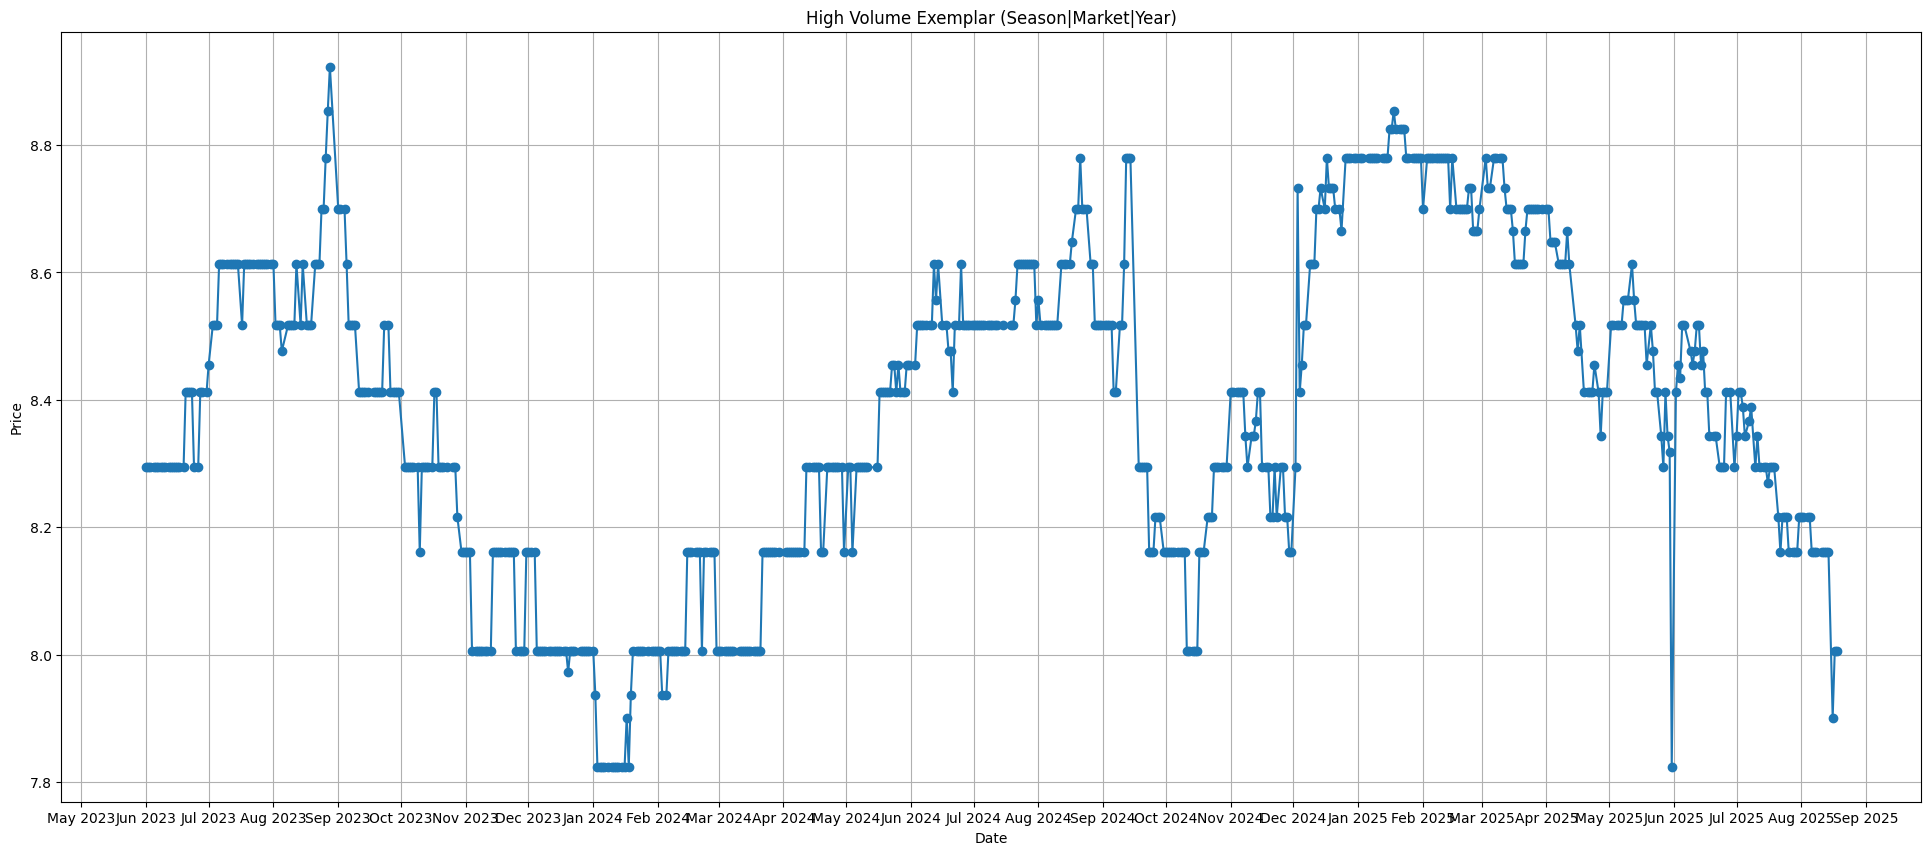

Feature: Season|Year
Different exemplars → plotting both
Representative Product: Leafy Vegetable|Other|FAQ
Representative Market: Thrippunithura


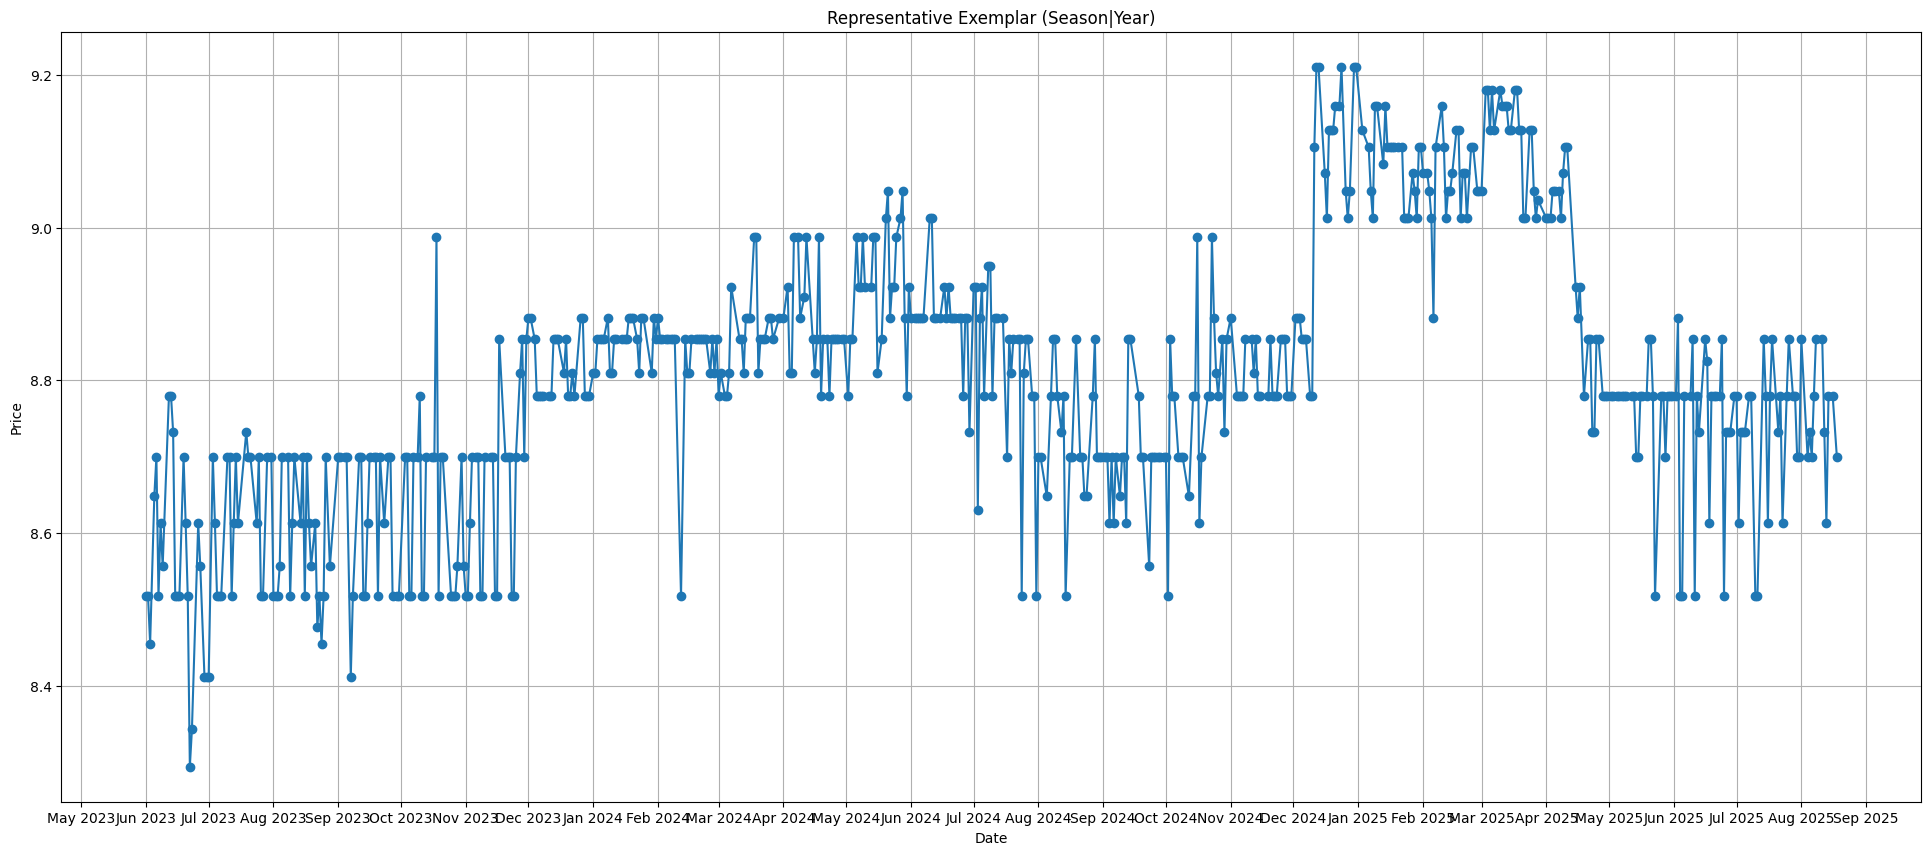

High Volume Product: Arecanut(Betelnut/Supari)|Supari|FAQ
High Volume Market: Perumbavoor


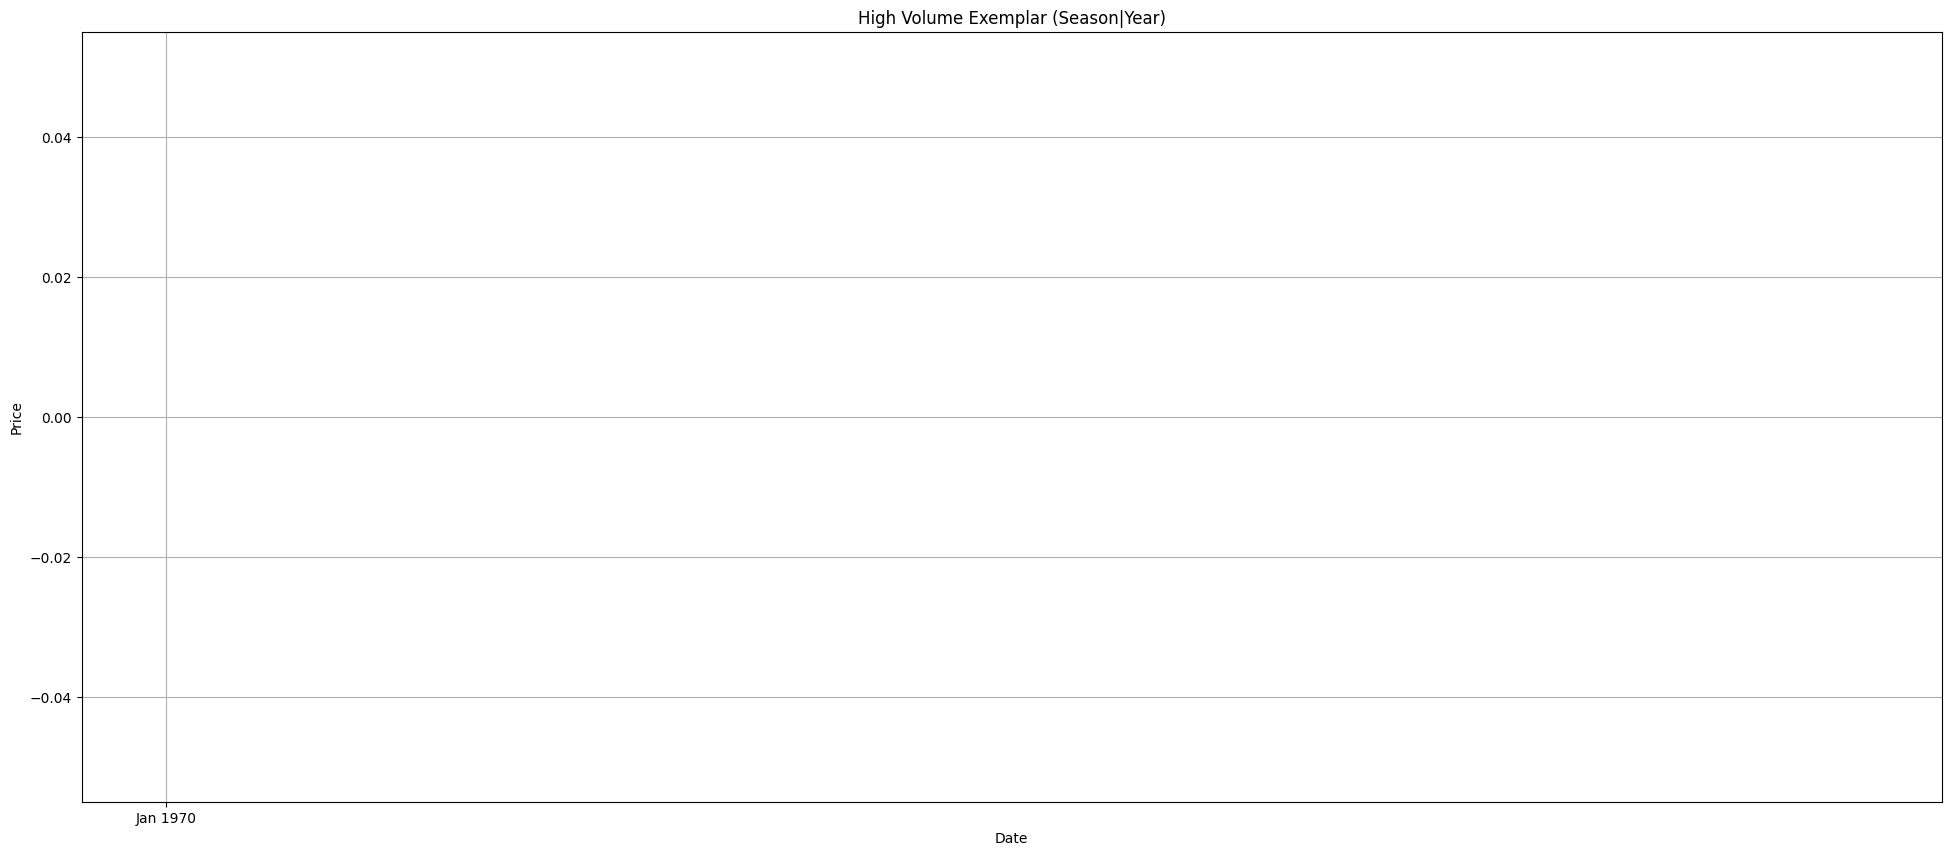

Feature: Year
Representative is the same as High Volume exemplar
Product: Ginger(Dry)|Dry|FAQ
Market: Perumbavoor


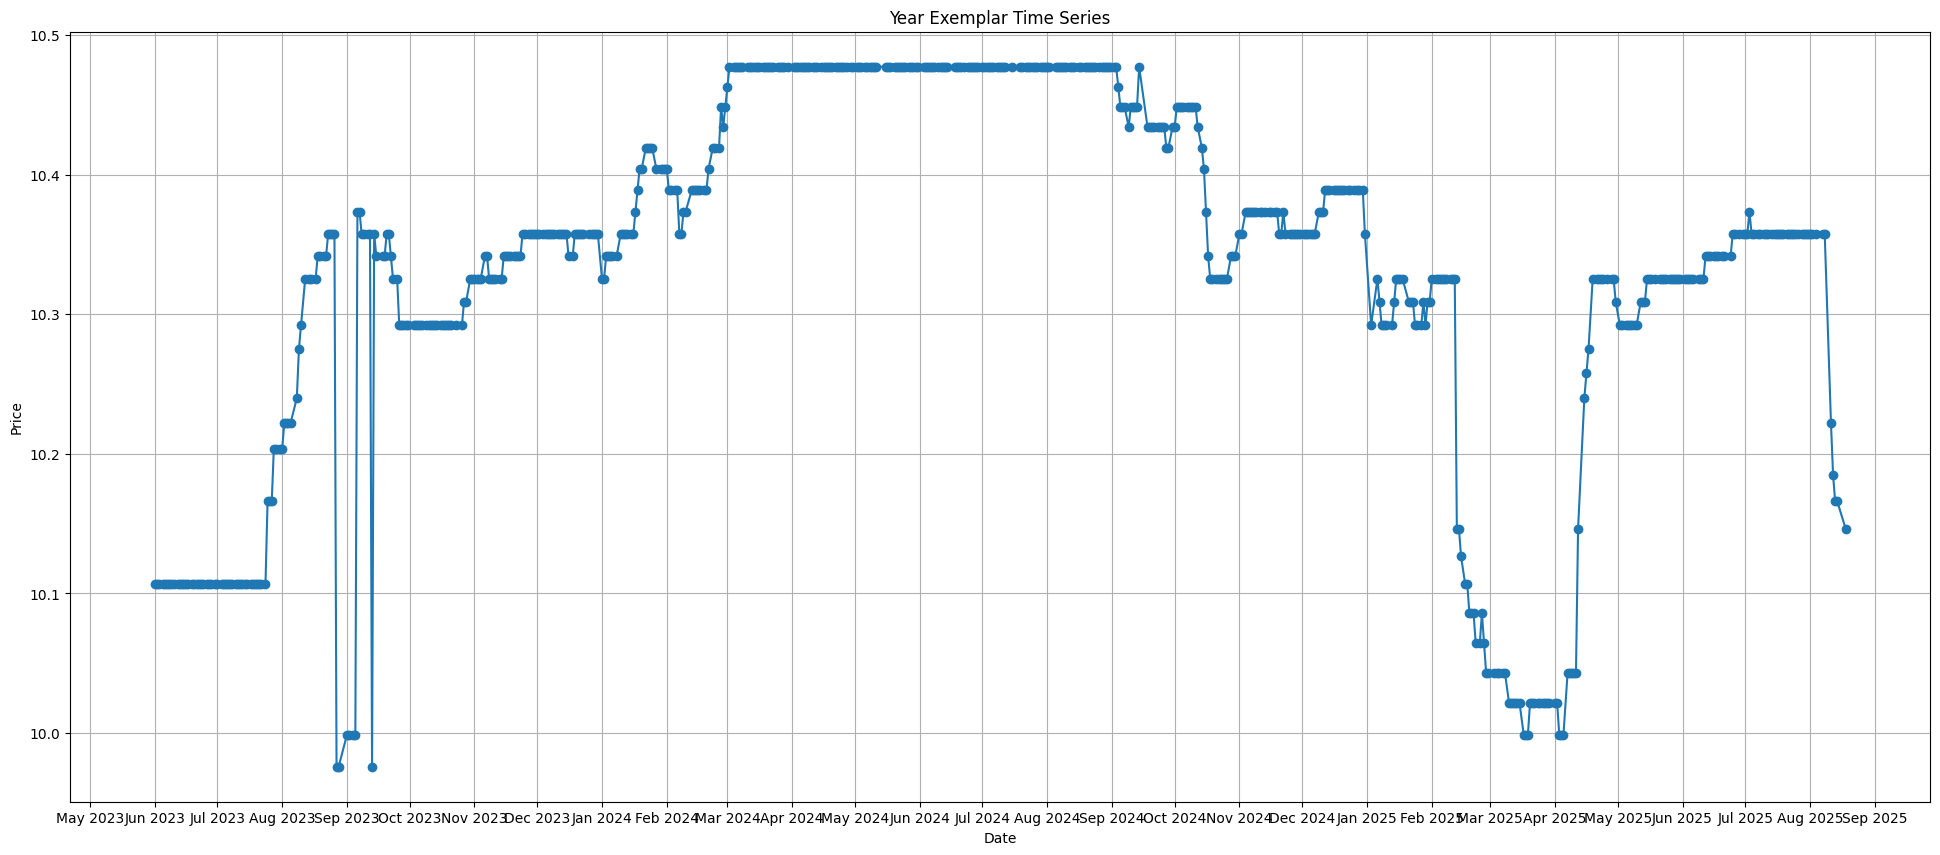

In [ ]:
# Loop through representative exemplars by feature
for feature in rep_exemplars.keys():
    
    # Focus only on season- and year-based exemplar groupings
    if "Season" in feature or "Year" in feature:
        print(f'Feature: {feature}')
        
        # Extract representative and high-volume time series
        df_rep, df_vol = time_series_extractor(df, feature, rep_exemplars, vol_exemplars)
        
        # Case 1: Both exemplars are the same → plot once
        if df_rep.equals(df_vol):
            print("Representative is the same as High Volume exemplar")
            print(f'Product: {rep_exemplars[feature][0]}')
            print(f'Market: {rep_exemplars[feature][1]}')
            
            plot_time_series(
                df_rep["log_Modal_Price"], 
                title=f"{feature} Exemplar Time Series"
            )
        
        # Case 2: Different exemplars → plot both for comparison
        else:
            print("Different exemplars → plotting both")
            
            print(f'Representative Product: {rep_exemplars[feature][0]}')
            print(f'Representative Market: {rep_exemplars[feature][1]}')
            plot_time_series(
                df_rep["log_Modal_Price"], 
                title=f"Representative Exemplar ({feature})"
            )
            
            print(f'High Volume Product: {vol_exemplars[feature][0]}')
            print(f'High Volume Market: {vol_exemplars[feature][1]}')
            plot_time_series(
                df_vol["log_Modal_Price"], 
                title=f"High Volume Exemplar ({feature})"
            )

## Summary of Log(Modal Price) Time Series

- **Normalization effect:**  
  Applying the log transform smoothed out extreme spikes in modal prices, making trends easier to interpret. Prices now reflect relative (percentage-like) changes rather than absolute jumps, which improves comparability across commodities.

- **Representative vs. High Volume exemplars:**  
  Across all groups, the two exemplar series move in very similar directions. This confirms that both selection methods capture the same underlying market signal, with differences mostly in noise or scale.

- **Trends observed:**  
  Several commodities display clear upward cycles followed by downward corrections, indicating seasonal or yearly influences. In some cases, long-term upward trends are visible, suggesting structural effects such as inflation or demand shifts.

- **Interpretability:**  
  On the log scale, shifts in the y-axis can be interpreted in terms of percentage changes in price. This makes seasonal and growth effects more consistent across commodities with very different price ranges.
